# Necessary Installs

In [ ]:
!pip install pymatgen matminer

In [ ]:
!pip install pandas openpyxl pymatgen

In [ ]:
!pip install shap scikit-learn matplotlib seaborn pandas

# Data Preprocessing and Featurization

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element

# CONFIG
IN_XLSX  = "CTE Value 10.xlsx"
OUT_XLSX = "CTE_with_Ionic_Stats_FINAL.xlsx"
OUT_POLY = "poly_descriptor_matrix.csv"
OUT_FEAT = "feature_matrix.csv"      # ionic stats + polyhedra only

# IONIC STATS
def compute_ionic_stats(formula):
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]

        ionic_radii = []
        atomic_masses = []
        symbols = []

        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)

            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)

        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid:
            return None, None, None

        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = var_radius ** 0.5
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None

        EXCLUDED = {"O"}
        cation_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        cation_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]

        if not cation_masses or not cation_fracs:
            return round(avg_radius, 4), (None if mismatch_pct is None else round(mismatch_pct, 2)), None

        total_frac = sum(cation_fracs) or 1.0
        norm_fracs = [f / total_frac for f in cation_fracs]

        mean_mass = sum(m * f for m, f in zip(cation_masses, norm_fracs))
        min_mass = min(cation_masses)
        max_mass = max(cation_masses)
        mass_diff_pct = ((max_mass - min_mass) / mean_mass) * 100 if mean_mass else None

        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mass_diff_pct is None else round(mass_diff_pct, 2),
        )

    except Exception as e:
        print(f"Error parsing {formula}: {e}")
        return None, None, None

# POLYHEDRA DESCRIPTORS
# Heuristic site buckets (A/B/C) + oxidation-state tagging → {El{ox}_tet|oct|multi: count}
RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}

COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts):
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}

    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"])
            A[el] = A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for site, capacity in (("B", "B"), ("C", "C")):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            if site=="A": A[el]=A.get(el,0)+take
            elif site=="B": B[el]=B.get(el,0)+take
            else: C[el]=C.get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto, metals):
    # For ABO3: caps (A=1, B=1). For spinel: (A=1, B=2). For pyrochlore: (A=2, B=2)
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B = {}, {}
    rest = metals.copy()

    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA)
            A[el] = A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB)
            B[el] = B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals, nO):
    target = 2.0 * nO
    els = list(metals.keys())
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None

    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None:
            return
        if i == len(els):
            if abs(cur - target) < 1e-6:
                best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})

    backtrack(0, 0.0, {})
    if best is None:
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []

    if "O" not in comp:
        return []
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals:
        return []

    proto = _detect_proto(comp)
    rows = []

    def emit(el, bucket, amt, ox=None):
        return {
            "Compound": formula,
            "Element": el,
            "CN_bucket": bucket,        # 'tet' | 'oct' | 'multi'
            "Count": float(amt),
            "Oxidation": None if ox is None else (int(ox) if float(ox).is_integer() else ox),
        }

    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:  # pyrochlore
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        # Generic oxide fallback: count metals as octahedral
        for el, amt in metals.items():
            rows.append(emit(el, "oct", amt))

    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el, bucket, ox):
    if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
        return f"{el}_{bucket}"
    try:
        oxi = int(round(float(ox)))
        return f"{el}{oxi}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def build_polyhedra_descriptor_matrix(formulas):
    """Return (poly_wide_df, used_desc_cols)"""
    long_rows = []
    uniq = pd.unique(pd.Series(formulas).dropna())
    for f in uniq:
        long_rows.extend(_poly_rows_for_formula(str(f)))

    if not long_rows:
        return pd.DataFrame({"Compound": uniq}), []

    poly_long = pd.DataFrame(long_rows)
    poly_long["desc"] = poly_long.apply(
        lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1
    )

    poly_wide = (
        poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                              aggfunc="sum", fill_value=0.0)
        .reset_index()
    )
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    desc_cols = [c for c in poly_wide.columns if c != "Compound"]
    return poly_wide, desc_cols

# MAIN
df = pd.read_excel(IN_XLSX)
if "Composition" not in df.columns:
    raise ValueError("Input file must contain a 'Composition' column.")

# Ionic stats
ion_stats = df["Composition"].apply(compute_ionic_stats).apply(pd.Series)
ion_stats.columns = ["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"]

# Polyhedra descriptors
poly_wide, desc_cols = build_polyhedra_descriptor_matrix(df["Composition"])
poly_wide.to_csv(OUT_POLY, index=False)

df_merged = df.copy()
df_merged = df_merged.merge(poly_wide, left_on="Composition", right_on="Compound", how="left")
if "Compound" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Compound"])

for col in ion_stats.columns:
    df_merged[col] = ion_stats[col].values

df_merged.to_excel(OUT_XLSX, index=False)

non_feature_cols = {"Composition", "a_A", "Lattice_A", "T_K", "Temperature", "Target", "Label"}
feat_cols = [c for c in df_merged.columns if c not in non_feature_cols]
pd.DataFrame(df_merged[feat_cols]).to_csv(OUT_FEAT, index=False)

print("Wrote:")
print(f"- {OUT_XLSX}  (original sheet + ionic stats + polyhedra features)")
print(f"- {OUT_POLY}   (standalone polyhedra descriptor matrix)")
print(f"- {OUT_FEAT}   (feature-only CSV)")


Error parsing Al2O3/(Y0.2Er0.2Yb0.2Ho0.2Lu0.2)3Al5O12: / is an invalid formula!
Error parsing AL2O3/(Y3Al5O12): / is an invalid formula!
Error parsing 0.5(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.5YSZ: 0.5 + 0.5 is an invalid formula!
Error parsing 0.25(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.75YSZ: 0.25 + 0.75 is an invalid formula!
Error parsing 0.167(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.833YSZ: 0.167 + 0.833 is an invalid formula!
Error parsing 0.125(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.875YSZ: 0.125 + 0.875 is an invalid formula!
Error parsing 0.07(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.93YSZ: 0.07 + 0.93 is an invalid formula!
Error parsing 0.05(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.95YSZ: 0.05 + 0.95 is an invalid formula!
Error parsing 0.03(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.97YSZ: 0.03 + 0.97 is an invalid formula!
Error parsing 0.02(La0.2Nd0.2Sm0.2Eu0.2Gd0.2)2Zr2O7 + 0.98YSZ: 0.02 + 0.98 is an invalid formula!
Error parsing (Y0.2Nd0.2Sm0.2Eu0.2Er0.2)AlO₃: ₃ is an invalid formula!
Erro

In [ ]:
import pandas as pd

file_path = "CTE_with_Ionic_Stats_FINAL.xlsx"
df = pd.read_excel(file_path)

df_filled = df.fillna(0)

print(df_filled.head())

df_filled.to_excel("Database_CTE_Focus_Cleaned.xlsx", index=False)

                                  Composition  CTE Value  Start Temp (°C)  \
0            (La0.2Sm0.2Eu0.2Yb0.2Y0.2)2Ce2O7   0.000013              600   
1  (La0.2Sm0.2Eu0.2Yb0.2Y0.2)2(Ce0.9Zr0.1)2O7   0.000013              600   
2  (La0.2Sm0.2Eu0.2Yb0.2Y0.2)2(Ce0.7Zr0.3)2O7   0.000012              600   
3  (La0.2Sm0.2Eu0.2Yb0.2Y0.2)2(Ce0.5Zr0.5)2O7   0.000012              600   
4              (Y0.25Yb0.25Ta0.25Nb0.25)2ZrO7   0.000011             1400   

   End Temp (°C)  Al-1_oct  Al3_oct  Al3_tet  As106_oct  Ba2_oct  Be3_oct  \
0           1350       0.0      0.0      0.0        0.0      0.0      0.0   
1           1350       0.0      0.0      0.0        0.0      0.0      0.0   
2           1350       0.0      0.0      0.0        0.0      0.0      0.0   
3           1350       0.0      0.0      0.0        0.0      0.0      0.0   
4           1400       0.0      0.0      0.0        0.0      0.0      0.0   

   ...  Yb3_multi  Yb3_oct  Zn2_oct  Zr4_multi  Zr4_oct  Zr6_oct  Zr7_oct 

In [ ]:
import pandas as pd
import re
from pymatgen.core.composition import Composition

def clean_formula(formula):
    return re.sub(r"\s*\(.*?\)", "", formula)

def extract_parentheses_substrings(s):
    return re.findall(r'\((.*?)\)', s)

def compstr_to_fractional(compstr, decimals=4):
    comp = Composition(compstr)
    return ''.join(f"{el.symbol}{round(comp.get_atomic_fraction(el), decimals)}" for el in comp.elements)

def normalize_composition(compstr, decimals=4):
    compstr = clean_formula(compstr)
    matches = extract_parentheses_substrings(compstr)
    for sub in matches:
        try:
            normalized = compstr_to_fractional(sub, decimals)
            compstr = compstr.replace(f"({sub})", normalized)
        except:
            pass
    try:
        return compstr_to_fractional(compstr, decimals)
    except:
        return "Invalid"

def get_pretty_formula(compstr, multiplier=100):
    try:
        comp = Composition(compstr)
        comp_dict = {el.symbol: int(comp.get_atomic_fraction(el) * multiplier) for el in comp.elements}
        return Composition(comp_dict).reduced_formula
    except:
        return "Invalid"

def batch_process(comp_series):
    results = []
    for raw in comp_series:
        cleaned = clean_formula(raw)
        norm = normalize_composition(cleaned)
        pretty = get_pretty_formula(norm)
        results.append({
            "Composition": raw,
            "Composition_clean": cleaned,
            "normalized": norm,
            "pretty_formula": pretty
        })
    return pd.DataFrame(results)

df = pd.read_excel("Database_CTE_Focus_Cleaned.xlsx")

composition_series = df["Composition"].dropna()
processed_df = batch_process(composition_series)

final_df = df.merge(processed_df, on="Composition", how="left")

final_df.to_csv("normalized_compositions_output.csv", index=False)


In [ ]:
import pandas as pd
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

df = pd.read_csv("normalized_compositions_output.csv")

df_valid = df[df["normalized"] != "Invalid"].copy()

df_valid["composition_obj"] = df_valid["normalized"].apply(lambda x: Composition(x))

featurizer = ElementProperty.from_preset("magpie")

features_df = featurizer.featurize_dataframe(df_valid, "composition_obj", ignore_errors=True)

features_df = features_df.drop(columns=["composition_obj"])

display(features_df.head())

features_df.to_csv("composition_features_pymatgen.csv", index=False)

ElementProperty:   0%|          | 0/134 [00:00<?, ?it/s]

,Composition,CTE Value,Start Temp (°C),End Temp (°C),Al-1_oct,Al3_oct,Al3_tet,As106_oct,Ba2_oct,Be3_oct,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
20,La2Ce2O7,0.000011,25,25,0,0.0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,12.0,194.0,182.0,78.1752,84.227795,12.0
31,(Dy0.167Ho0.167Er0.167Tm0.167Yb0.167Y0.167)PO4,0.000006,25,25,0,0.0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,2.0,12.0,10.0,10.0000,3.200000,12.0
32,Y2SiO5,0.000007,25,25,0,0.0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,12.0,227.0,215.0,84.3750,90.468750,12.0
37,Yb2SiO5,0.000007,25,25,0,0.0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,12.0,227.0,215.0,92.1250,100.156250,12.0
47,(Y0.16Zr0.84)O1.92,0.000010,26,1300,0,0.0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,12.0,12.0,0.0,12.0000,0.000000,12.0


# Correlation Matrix

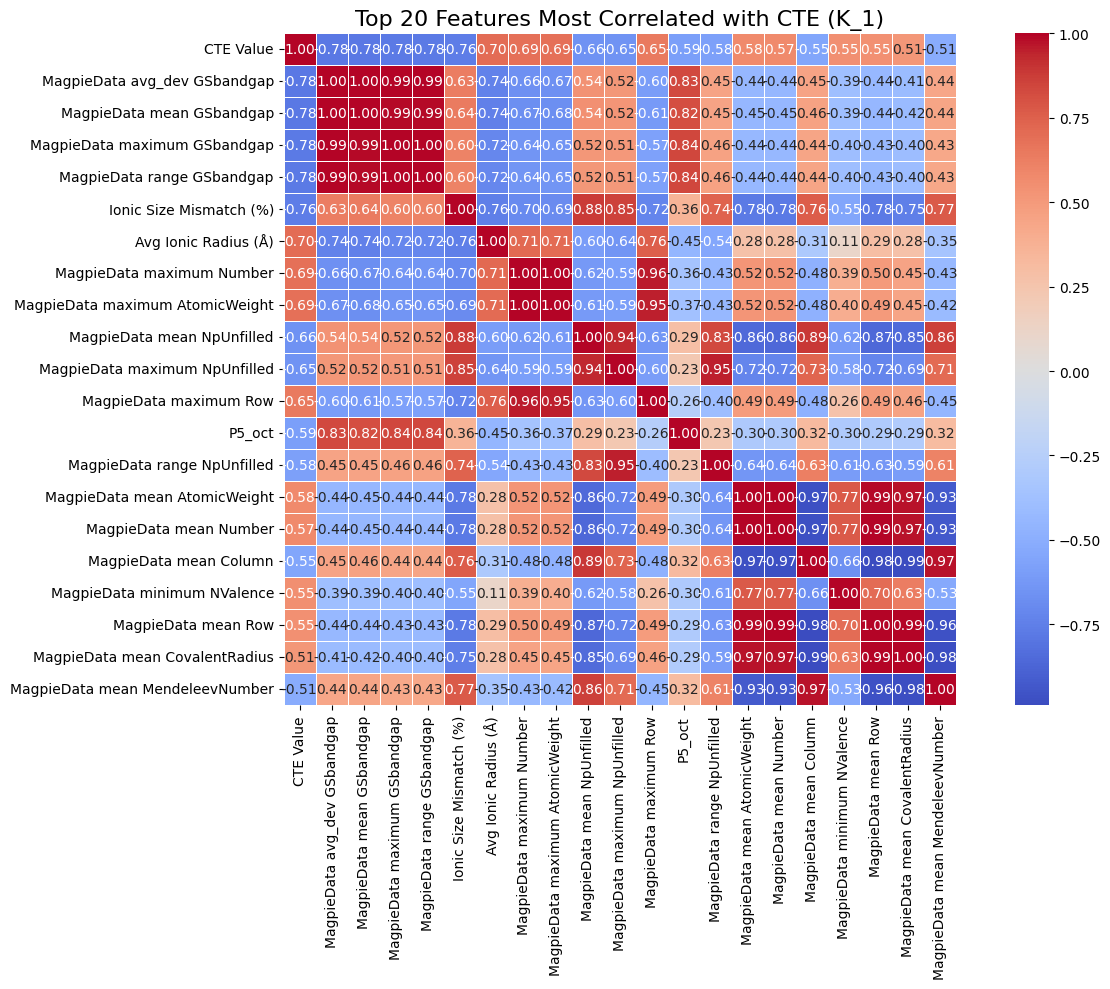

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("composition_features_pymatgen.csv")

drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 54']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr(method='pearson')

target = "CTE Value"
top20_features = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(20).index.tolist()

top20_with_target = [target] + top20_features

top_corr_matrix = corr_matrix.loc[top20_with_target, top20_with_target]

plt.figure(figsize=(14, 10))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Top 20 Features Most Correlated with CTE (K_1)", fontsize=16)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1579272259.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_corr_signed.values, y=top20_corr_signed.index, palette="coolwarm", orient='h')


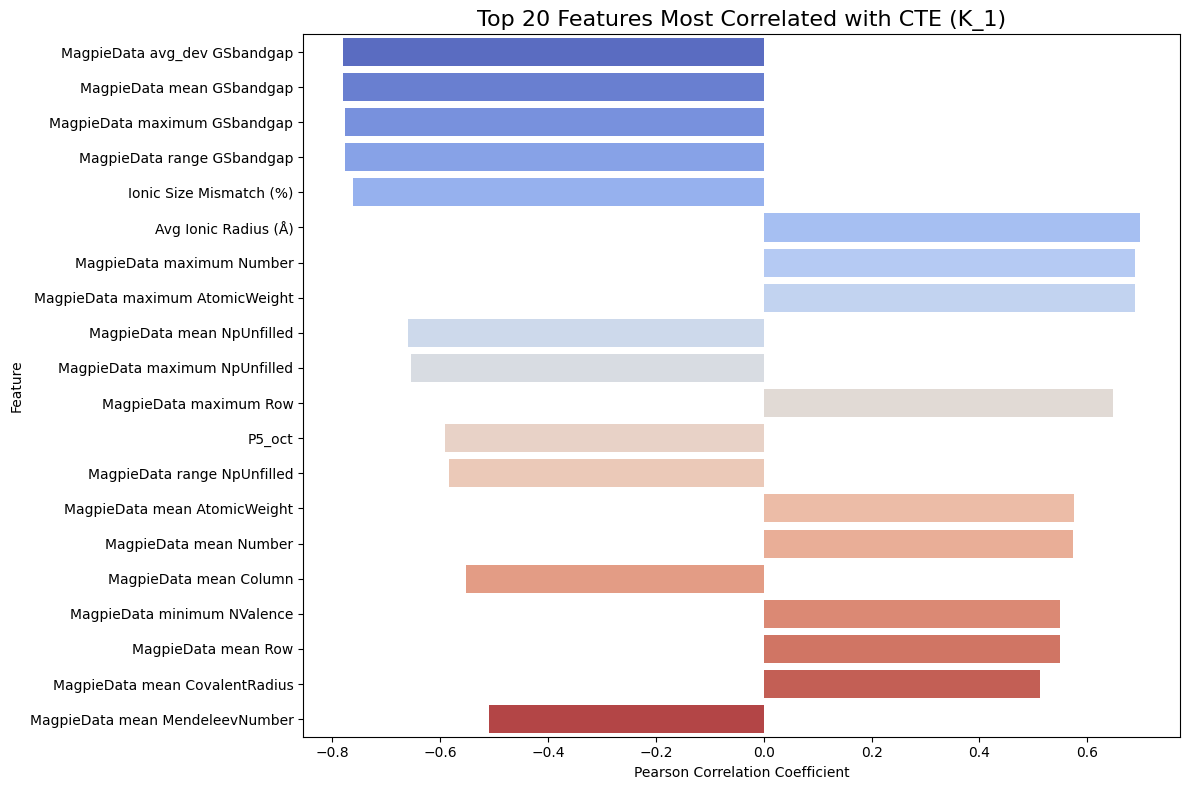

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("composition_features_pymatgen.csv")

drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 54']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

numeric_df = df.select_dtypes(include='number')

target = "CTE Value"
correlations = numeric_df.corr(method='pearson')[target].drop(target)

top20_corr = correlations.abs().sort_values(ascending=False).head(20)
top20_corr_signed = correlations[top20_corr.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=top20_corr_signed.values, y=top20_corr_signed.index, palette="coolwarm", orient='h')
plt.title("Top 20 Features Most Correlated with CTE (K_1)", fontsize=16)
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2491579937.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


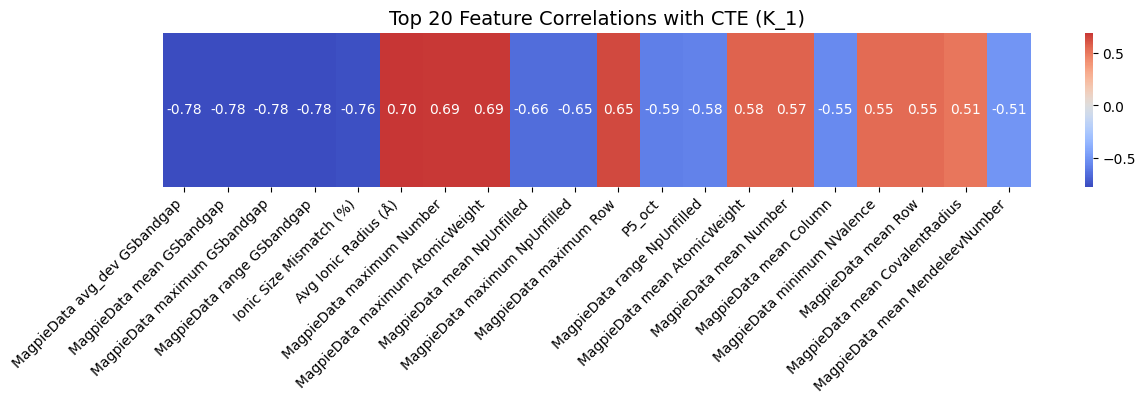

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("composition_features_pymatgen.csv")

drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 54']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

numeric_df = df.select_dtypes(include='number')


target = "CTE Value"
correlations = numeric_df.corr(method='pearson')[target].drop(target)

top20_corr = correlations.abs().sort_values(ascending=False).head(20)
top20_corr_signed = correlations[top20_corr.index]

corr_matrix = pd.DataFrame(top20_corr_signed).T

plt.figure(figsize=(14, 2))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, cbar=True, fmt=".2f")
plt.title("Top 20 Feature Correlations with CTE (K_1)", fontsize=14)
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Base Models

Shape of X after dropping columns: (134, 220)
Shape of X after dropping NaNs: (134, 220)

RandomForest:
y_test sample: [1.087e-05 9.240e-06 1.160e-05 3.000e-07 1.000e-05]
y_pred sample: [1.08699000e-05 6.88425714e-06 1.15176000e-05 7.39600000e-07
 1.25673000e-05]
R² = 0.917, RMSE = 1.385726e-06, MSE = 1.920235e-12

GradientBoosting:
y_test sample: [1.087e-05 9.240e-06 1.160e-05 3.000e-07 1.000e-05]
y_pred sample: [ 1.09918984e-05  8.15919392e-06  1.13410440e-05 -3.93052386e-07
  1.28216827e-05]
R² = 0.835, RMSE = 1.955765e-06, MSE = 3.825019e-12

SVR:
y_test sample: [1.087e-05 9.240e-06 1.160e-05 3.000e-07 1.000e-05]
y_pred sample: [1.06355456e-05 8.07122362e-06 1.06324348e-05 7.29782411e-06
 1.18500151e-05]
R² = 0.258, RMSE = 4.154422e-06, MSE = 1.725922e-11

KNN:
y_test sample: [1.087e-05 9.240e-06 1.160e-05 3.000e-07 1.000e-05]
y_pred sample: [1.3190e-05 3.2420e-06 1.1306e-05 9.1780e-06 1.6200e-05]
R² = 0.415, RMSE = 3.687122e-06, MSE = 1.359487e-11

XGBoost:
y_test sample: [1.087e-

/tmp/ipython-input-3598596169.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-3598596169.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
/tmp/ipython-input-3598596169.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)


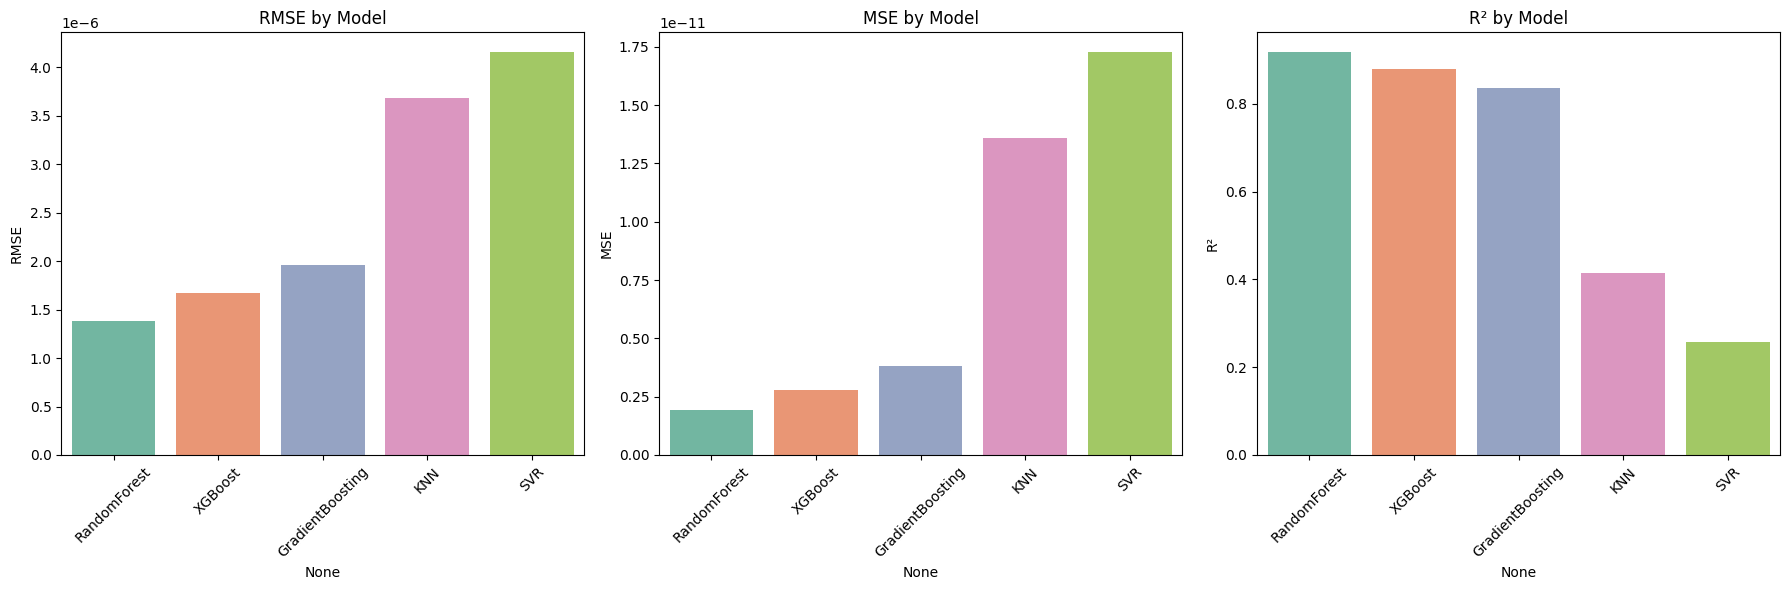

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

df = pd.read_csv("composition_features_pymatgen.csv")
drop_cols = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", 'Unnamed: 0']
cols_to_drop = [col for col in drop_cols if col in df.columns]

target_column = "CTE Value"
if target_column in df.columns:
    y = df[target_column]
    X = df.drop(columns=[target_column] + cols_to_drop, errors='ignore')
else:
    raise ValueError(f"Target column '{target_column}' not found in the DataFrame.")

X = X.select_dtypes(include=np.number)

print("Shape of X after dropping columns:", X.shape)

X = X.dropna()
y = y.loc[X.index]

print("Shape of X after dropping NaNs:", X.shape)


y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=0),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}
if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=0)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(y_pred, "flatten"):
        y_pred = y_pred.flatten()

    y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_orig = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mse = np.mean((y_test_orig - y_pred_orig) ** 2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_orig, y_pred_orig)

    results[name] = {
        "model": model, "MSE": mse, "RMSE": rmse, "R²": r2
    }

    print(f"\n{name}:")
    print(f"y_test sample: {y_test_orig[:5]}")
    print(f"y_pred sample: {y_pred_orig[:5]}")
    print(f"R² = {r2:.3f}, RMSE = {rmse:.6e}, MSE = {mse:.6e}")

metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)

palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X shape (pre-split): (134, 220)  |  #features used: 220
✓ Saved target scaler → y_scaler.joblib
   RandomForest: R²= 0.8628 | RMSE= 1.786347e-06 | MSE= 3.191035e-12
GradientBoosting: R²= 0.8355 | RMSE= 1.955765e-06 | MSE= 3.825019e-12
     ExtraTrees: R²= 0.8113 | RMSE= 2.094685e-06 | MSE= 4.387704e-12
   DecisionTree: R²= 0.7354 | RMSE= 2.480147e-06 | MSE= 6.151130e-12
        HistGBR: R²= 0.8102 | RMSE= 2.100972e-06 | MSE= 4.414085e-12
       AdaBoost: R²= 0.8465 | RMSE= 1.888910e-06 | MSE= 3.567983e-12
     Bagging_RF: R²= 0.8765 | RMSE= 1.694411e-06 | MSE= 2.871030e-12
          Ridge: R²= 0.7611 | RMSE= 2.356784e-06 | MSE= 5.554432e-12
          Lasso: R²= 0.7386 | RMSE= 2.465413e-06 | MSE= 6.078262e-12
     ElasticNet: R²= 0.5842 | RMSE= 3.109304e-06 | MSE= 9.667772e-12
  BayesianRidge: R²= 0.8146 | RMSE= 2.076012e-06 | MSE= 4.309824e-12
          Huber: R²= 0.5316 | RMSE= 3.300176e-06 | MSE= 1.089116e-11
       TheilSen: R²=-13362.4835 | RMSE= 5.574120e-04 | MSE= 3.107081e-07
Tw

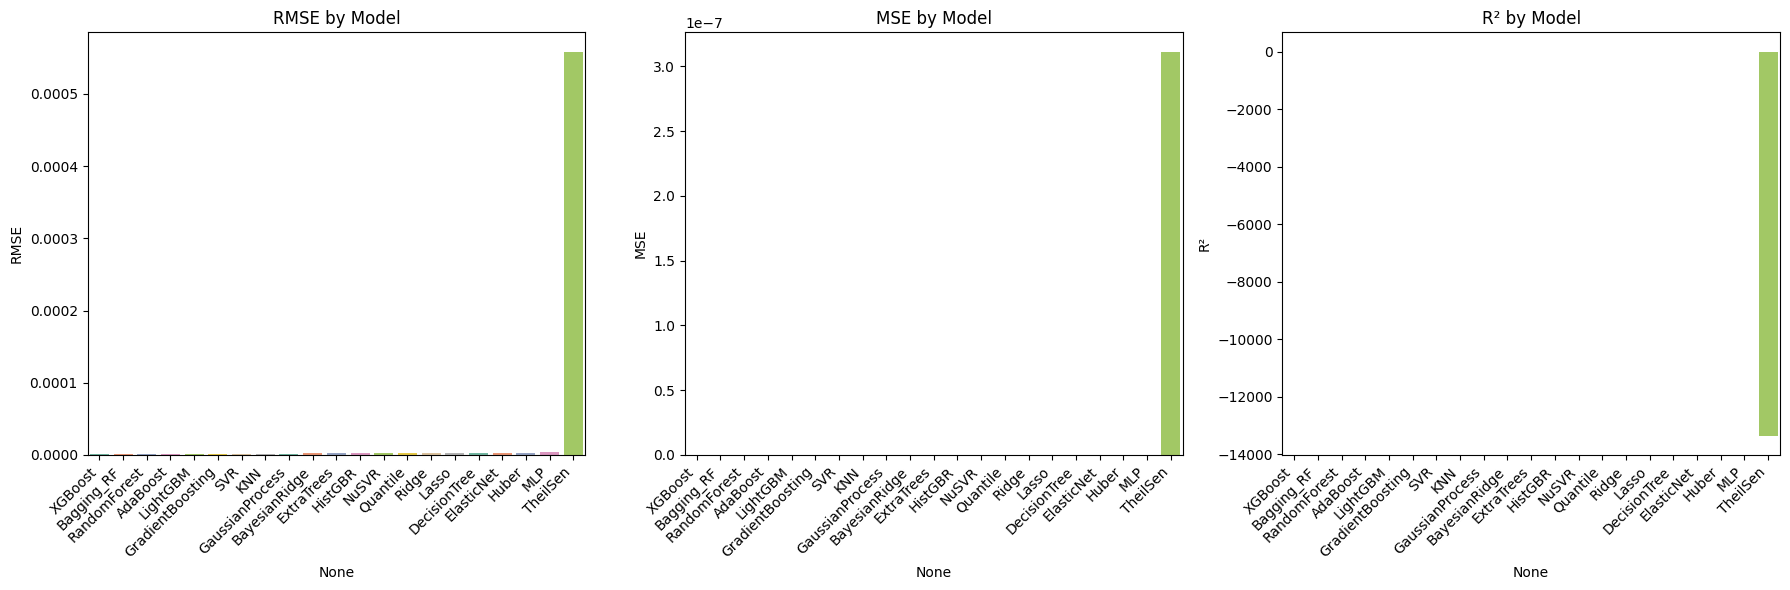

In [ ]:
import warnings, os, numpy as np, pandas as pd
import shap, matplotlib.pyplot as plt, seaborn as sns
from joblib import dump
from typing import Tuple, Dict, Any

from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor, StackingRegressor, VotingRegressor,
    AdaBoostRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, TheilSenRegressor,
    TweedieRegressor, QuantileRegressor
)
from sklearn.svm import SVR, NuSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")

# Config
DATA_PATH = "composition_features_pymatgen.csv"
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"
RESULTS_JOBLIB = "results_models.joblib"
Y_SCALER_JOBLIB = "y_scaler.joblib"
USE_Y_SCALER = True

DROP_COLS = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", "Unnamed: 0"]

xgb_available = lgb_available = cat_available = False
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    pass
try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    pass
try:
    from catboost import CatBoostRegressor
    cat_available = True
except Exception:
    pass

# Load data
df = pd.read_csv(DATA_PATH)
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found: {df.columns.tolist()[:20]} ...")
y = df[TARGET].astype(float)

def get_feature_columns(df: pd.DataFrame) -> list:
    if os.path.exists(SELECTED_FEATS_FILE):
        with open(SELECTED_FEATS_FILE, "r") as f:
            feats = [ln.strip() for ln in f if ln.strip()]
        missing = [c for c in feats if c not in df.columns]
        if missing:
            print(f"[INFO] {len(missing)} selected features missing from CSV. Examples: {missing[:6]}")
            for c in missing:
                df[c] = np.nan
        return feats
    return df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns], errors="ignore")\
             .select_dtypes(include=np.number).columns.tolist()

feature_cols = get_feature_columns(df)
X = df[feature_cols].copy()

mask = y.notna()
X, y = X.loc[mask], y.loc[mask]

print(f"X shape (pre-split): {X.shape}  |  #features used: {len(feature_cols)}")

# Helpers: model wrappers
def scaled_model(estimator) -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

def tree_model(estimator) -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("model", estimator),
    ])

if USE_Y_SCALER:
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()
    dump(y_scaler, Y_SCALER_JOBLIB)
    print(f"✓ Saved target scaler → {Y_SCALER_JOBLIB}")
else:
    y_scaled = y.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_scaled, test_size=0.2, random_state=42
)

# Build model zoo
models = {
    # Trees
    "RandomForest": tree_model(RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=0, n_jobs=-1)),
    "GradientBoosting": tree_model(GradientBoostingRegressor(random_state=0)),
    "ExtraTrees": tree_model(ExtraTreesRegressor(n_estimators=600, random_state=0, n_jobs=-1)),
    "DecisionTree": tree_model(DecisionTreeRegressor(random_state=0)),
    "HistGBR": tree_model(HistGradientBoostingRegressor(random_state=0)),
    "AdaBoost": tree_model(AdaBoostRegressor(n_estimators=300, random_state=0)),
    "Bagging_RF": tree_model(BaggingRegressor(
        estimator=RandomForestRegressor(n_estimators=80, random_state=0, n_jobs=-1),
        n_estimators=20, random_state=0
    )),

    # Linear & regularized
    "Ridge": scaled_model(Ridge(alpha=1.0, random_state=0)),
    "Lasso": scaled_model(Lasso(alpha=1e-3, random_state=0, max_iter=10000)),
    "ElasticNet": scaled_model(ElasticNet(alpha=1e-3, l1_ratio=0.5, random_state=0, max_iter=10000)),
    "BayesianRidge": scaled_model(BayesianRidge()),
    "Huber": scaled_model(HuberRegressor()),
    "TheilSen": scaled_model(TheilSenRegressor()),
    "Tweedie": scaled_model(TweedieRegressor(power=1, alpha=0.5)),
    "Quantile": scaled_model(QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs")),

    # SVM/KNN
    "SVR": scaled_model(SVR(C=10.0, epsilon=0.01, kernel="rbf")),
    "NuSVR": scaled_model(NuSVR(kernel="rbf", C=1.0, nu=0.5)),
    "KNN": scaled_model(KNeighborsRegressor(n_neighbors=7)),

    # Neural net
    "MLP": scaled_model(MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=0)),

    # Gaussian Process
    "GaussianProcess": scaled_model(GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        normalize_y=True, random_state=0
    )),

}

if xgb_available:
    models["XGBoost"] = tree_model(XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, tree_method="hist"
    ))
if lgb_available:
    models["LightGBM"] = tree_model(LGBMRegressor(
        n_estimators=800, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=0, n_jobs=-1
    ))
if cat_available:
    models["CatBoost"] = tree_model(CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6, random_seed=0, verbose=False
    ))

# Train & evaluate
def inverse_target(z: np.ndarray) -> np.ndarray:
    if USE_Y_SCALER:
        return y_scaler.inverse_transform(z.reshape(-1, 1)).ravel()
    return z

results: Dict[str, Dict[str, Any]] = {}
for name, mdl in models.items():
    try:
        mdl.fit(X_train, y_train)
        y_pred = np.asarray(mdl.predict(X_test)).ravel()

        y_pred_orig = inverse_target(y_pred)
        y_test_orig = inverse_target(y_test)

        mse = mean_squared_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_orig, y_pred_orig)

        results[name] = {"model": mdl, "MSE": mse, "RMSE": rmse, "R²": r2}
        print(f"{name:>15}: R²={r2: .4f} | RMSE={rmse: .6e} | MSE={mse: .6e}")
    except Exception as e:
        print(f"{name} failed: {e}")

metrics_df = pd.DataFrame(results).T[["MSE", "RMSE", "R²"]].sort_values("R²", ascending=False)
print("\n=== Summary (sorted by R²) ===")
print(metrics_df)

dump(results, RESULTS_JOBLIB)
print(f"\n✓ Saved models + metrics → {RESULTS_JOBLIB}")

# Metric plots
palette = sns.color_palette("Set2", len(metrics_df))
color_dict = dict(zip(metrics_df.index, palette))

plt.figure(figsize=(18, 6))
for i, metric in enumerate(["RMSE", "MSE", "R²"]):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x=metrics_df.index, y=metric, data=metrics_df, palette=color_dict)
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Unified inference with feature_engineer + selected_features + (results OR joblib)
# - Writes feature_engineer.py
# - Loads selected_features.txt
# - Builds features for new_formulas
# - Predicts with either:
#     (A) every model in results, applying y_scaler.inverse_transform if available, OR
#     (B) cte_model_rf.joblib
# Saves: cte_predictions_all_models.csv

# Colab deps
try:
    IN_COLAB = "google.colab" in str(get_ipython())
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !pip -q install pymatgen==2024.5.1 matminer==0.9.0 scikit-learn==1.4.2 pandas==2.2.2 joblib==1.4.2

import os, re, textwrap, importlib.util
import numpy as np, pandas as pd
from joblib import load, dump
from sklearn.pipeline import Pipeline

# Config
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"
MODEL_JOBLIB = "cte_model_rf.joblib"
FEATURE_MODULE = "feature_engineer.py"
ALLOW_MISSING_FEATURES = True

new_formulas = [
"Y3Al5O12",
"Y1.5Dy1.5Al5O12",
"Y.9999Dy.9999Ho.9999Al5O12",
"Y.75Dy.75Ho.75Er.75Al5O12",
"Y.6La.6Dy.6Ho.6Er.6Al5O12",
"Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
"Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
"(Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.1666…)",
"(Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285Ho0.14285…)",
"Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12",
"Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12",
"Y3Fe5O12",
"Y3Fe2.50Al2.50O12",
"Y3Fe2.475Al2.475Mn0.05O12",
"Y3Fe2.475Al2.475Co0.05O12",
"Y3Fe2.475Al2.475Ni0.05O12",
"Y3Fe2.475Al2.475Cu0.05O12",
"Y3Fe2.45Al2.45Mn0.025Co0.025Ni0.025Cu0.025O12",
"La.666Gd.666Lu.666TiZrO7",
"Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
"Pr.4Sm.4Gd.4Ho.4Lu2Ti2O7",
"Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
"Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
"Eu.5Gd.5Ho.5Er.5Ti2O7",
"GdHoTi2O7",
"Nd.4Sm.4Eu.4Gd.4Dy.4Ti2O7",
"Eu0.5Gd0.5Ho0.5Yb0.5Ti2O7",
]

# Write feature_engineer.py

fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Dict, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from pymatgen.core.periodic_table import Element
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            if ox_state is not None and hasattr(el, "ionic_radii") and el.ionic_radii:
                radius = el.ionic_radii.get(ox_state, None)
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)
        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid: return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for r, f in zip(radii, fracs))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None
        EXCLUDED = {"O"}
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s not in EXCLUDED]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s not in EXCLUDED]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None
        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

RARE_EARTHS = {"La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y","Sc"}
A_LIKE = RARE_EARTHS | {"Ba","Sr","Ca","K","Na","Pb","Bi"}
B_LIKE = {"Al","Ga","In","Fe","Co","Ni","Mn","Cr","V","Nb","Ta","Ti","Zr","Hf","Sn","Ge","Si","Mo","W","Cu","Mg","Zn"}
COMMON_VALENCES = {
    "La":[3],"Ce":[3,4],"Pr":[3,4],"Nd":[3],"Sm":[3],"Eu":[2,3],"Gd":[3],"Tb":[3,4],"Dy":[3],"Ho":[3],
    "Er":[3],"Tm":[3],"Yb":[2,3],"Lu":[3],"Y":[3],"Sc":[3],
    "Ba":[2],"Sr":[2],"Ca":[2],"K":[1],"Na":[1],
    "Al":[3],"Ga":[3],"In":[3],"Fe":[2,3],"Co":[2,3],"Ni":[2,3],"Mn":[2,3,4],"Cr":[3],"V":[3,5],
    "Nb":[5],"Ta":[5],"Ti":[4,3],"Zr":[4],"Hf":[4],"Sn":[4,2],"Ge":[4],"Si":[4],
    "Mo":[6,5],"W":[6,5],"Cu":[1,2],"Mg":[2],"Zn":[2],
    "Pb":[2,4],"Bi":[3]
}

def _detect_proto(counts: Dict[str,float]) -> str:
    nO = counts.get("O", 0.0)
    metals = {k:v for k,v in counts.items() if k != "O"}
    ncat = sum(metals.values())
    if nO > 0 and abs(nO - 12) <= 0.3 and abs(ncat - 8) <= 0.3:  return "GARNET_A3B2C3O12"
    if nO > 0 and abs(nO - 7)  <= 0.3 and abs(ncat - 4) <= 0.3:  return "PYRO_A2B2O7"
    if nO > 0 and abs(nO - 4)  <= 0.3 and abs(ncat - 3) <= 0.3:  return "SPINEL_AB2O4"
    if nO > 0 and abs(nO - 3)  <= 0.3 and abs(ncat - 2) <= 0.3:  return "PEROV_ABO3"
    return "GEN_OXIDE"

def _split_sites_garnet(metals: Dict[str,float]):
    A, B, C = {}, {}, {}
    rest = metals.copy()
    cap = {"A":3.0, "B":2.0, "C":3.0}
    for el in list(rest.keys()):
        if el in A_LIKE and cap["A"] > 0:
            take = min(rest[el], cap["A"]); A[el]=A.get(el,0)+take; rest[el]-=take; cap["A"]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("B","C"):
        for el in list(rest.keys()):
            if el in B_LIKE and cap[site] > 0:
                take = min(rest[el], cap[site])
                (B if site=="B" else C)[el] = (B if site=="B" else C).get(el,0)+take
                rest[el]-=take; cap[site]-=take
                if rest[el] <= 1e-12: rest.pop(el, None)
    for site in ("A","B","C"):
        while cap[site] > 1e-12 and rest:
            el = max(rest.items(), key=lambda kv: kv[1])[0]
            take = min(rest[el], cap[site])
            (A if site=="A" else B if site=="B" else C)[el] = (A if site=="A" else B if site=="B" else C).get(el,0)+take
            rest[el]-=take; cap[site]-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    return A, B, C

def _split_sites_binary(proto: str, metals: Dict[str,float]):
    caps = {"PEROV_ABO3": (1.0,1.0), "SPINEL_AB2O4": (1.0,2.0), "PYRO_A2B2O7": (2.0,2.0)}
    capA, capB = caps.get(proto, (1.0,1.0))
    A, B, rest = {}, {}, metals.copy()
    for el in list(rest.keys()):
        if el in A_LIKE and capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if el in B_LIKE and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
            if rest[el] <= 1e-12: rest.pop(el, None)
    for el in list(rest.keys()):
        if capA > 0:
            take = min(rest[el], capA); A[el]=A.get(el,0)+take; rest[el]-=take; capA-=take
        if rest.get(el,0) > 0 and capB > 0:
            take = min(rest[el], capB); B[el]=B.get(el,0)+take; rest[el]-=take; capB-=take
        if rest.get(el,0) <= 1e-12: rest.pop(el, None)
    return A, B

def _guess_valences(metals: Dict[str,float], nO: float) -> Dict[str,float]:
    target = 2.0 * nO
    els = list(metals.keys())
    cand = [COMMON_VALENCES.get(el, [3]) for el in els]
    best = None
    def backtrack(i, cur, assign):
        nonlocal best
        if best is not None: return
        if i == len(els):
            if abs(cur - target) < 1e-6: best = dict(assign)
            return
        el = els[i]; amt = metals[el]
        for v in cand[i][:3]:
            backtrack(i+1, cur + v*amt, {**assign, el: v})
    backtrack(0, 0.0, {})
    if best is None:
        best = {el: (3 if el in RARE_EARTHS else cand[i][0]) for i, el in enumerate(els)}
        cur = sum(best[el]*metals[el] for el in els)
        if els and abs(target - cur) > 1e-9:
            last = els[-1]
            if metals[last] != 0:
                best[last] = best[last] + (target - cur) / metals[last]
    for k, v in list(best.items()):
        if np.isfinite(v):
            vi = int(round(v))
            best[k] = vi if abs(vi - v) < 0.25 else v
    return best

def _poly_rows_for_formula(formula: str):
    try:
        comp = Composition(formula).get_el_amt_dict()
    except Exception:
        return []
    if "O" not in comp: return []
    nO = float(comp["O"])
    metals = {k: float(v) for k, v in comp.items() if k != "O" and v > 0}
    if not metals: return []
    proto = _detect_proto(comp)
    rows = []
    def emit(el, bucket, amt, ox=None):
        return {"Compound": formula, "Element": el, "CN_bucket": bucket, "Count": float(amt), "Oxidation": ox}
    if proto == "GARNET_A3B2C3O12":
        A, B, C = _split_sites_garnet(metals)
        for el, amt in A.items(): rows.append(emit(el, "multi", amt))
        for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        for el, amt in C.items(): rows.append(emit(el, "tet",   amt))
    elif proto in ("PEROV_ABO3", "SPINEL_AB2O4", "PYRO_A2B2O7"):
        A, B = _split_sites_binary(proto, metals)
        if proto == "PEROV_ABO3":
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        elif proto == "SPINEL_AB2O4":
            for el, amt in A.items(): rows.append(emit(el, "tet",   amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
        else:
            for el, amt in A.items(): rows.append(emit(el, "multi", amt))
            for el, amt in B.items(): rows.append(emit(el, "oct",   amt))
    else:
        for el, amt in metals.items(): rows.append(emit(el, "oct", amt))
    oxmap = _guess_valences(metals, nO)
    for r in rows:
        el = r["Element"]
        if el in oxmap and np.isfinite(oxmap[el]):
            oxv = oxmap[el]
            r["Oxidation"] = int(oxv) if float(oxv).is_integer() else oxv
    return rows

def _desc_name(el: str, bucket: str, ox) -> str:
    try:
        if ox is None or (isinstance(ox, float) and not np.isfinite(ox)):
            return f"{el}_{bucket}"
        return f"{el}{int(round(float(ox)))}_{bucket}"
    except Exception:
        return f"{el}_{bucket}"

def _build_polyhedra_descriptor_matrix(formulas: List[str]) -> pd.DataFrame:
    rows = []
    for f in pd.unique(pd.Series(formulas).dropna()):
        rows.extend(_poly_rows_for_formula(_normalize_formula(f)))
    if not rows:
        return pd.DataFrame(index=range(len(formulas)))
    poly_long = pd.DataFrame(rows)
    poly_long["desc"] = poly_long.apply(lambda r: _desc_name(r["Element"], r["CN_bucket"], r["Oxidation"]), axis=1)
    poly_wide = (poly_long.pivot_table(index="Compound", columns="desc", values="Count",
                                       aggfunc="sum", fill_value=0.0).reset_index())
    poly_wide = poly_wide.loc[:, ~poly_wide.columns.duplicated()].copy()
    poly_wide.rename(columns={"Compound": "formula_key"}, inplace=True)
    return poly_wide

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [ _compute_ionic_stats(f) for f in f_norm ]
    ion = pd.DataFrame(ion, columns=["Avg Ionic Radius (Å)", "Ionic Size Mismatch (%)", "Atomic Mass Diff (%)"])
    base = pd.concat([base, ion], axis=1)
    poly = _build_polyhedra_descriptor_matrix(f_norm)
    base = base.merge(poly, on="formula_key", how="left")
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
with open(FEATURE_MODULE, "w") as f:
    f.write(textwrap.dedent(fe_code))
print(f"✓ Wrote {FEATURE_MODULE}")

# Load featurizer module
spec = importlib.util.spec_from_file_location("feature_engineer", FEATURE_MODULE)
fe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fe)
assert hasattr(fe, "build_feature_matrix"), "feature_engineer.py must define build_feature_matrix(formulas) -> DataFrame"

# Build features for new_formulas
X_new_full = fe.build_feature_matrix(new_formulas)
X_new_full.to_csv("new_formulas_features_raw.csv", index=False)
print(f"✓ Built features for {len(new_formulas)} formulas")

# Load selected features
def load_selected_features():
    if os.path.exists(SELECTED_FEATS_FILE):
        with open(SELECTED_FEATS_FILE, "r") as f:
            feats = [ln.strip() for ln in f if ln.strip()]
        if feats:
            return feats
    if os.path.exists(MODEL_JOBLIB):
        mdl = load(MODEL_JOBLIB)
        try:
            return list(mdl.named_steps.get("rf", mdl).feature_names_in_)
        except Exception:
            pass
    try:
        _ = results
        if isinstance(results, dict) and results:
            first_model = next(iter(results.values()))["model"]
            if hasattr(first_model, "feature_names_in_"):
                return list(first_model.feature_names_in_)
            if isinstance(first_model, Pipeline):
                for stepname, step in first_model.steps:
                    if hasattr(step, "feature_names_in_"):
                        return list(step.feature_names_in_)
    except Exception:
        pass
    raise FileNotFoundError(
        f"Could not load selected features from '{SELECTED_FEATS_FILE}' "
        "and could not infer from a saved model."
    )

selected_features = load_selected_features()
print(f"✓ Selected features loaded ({len(selected_features)})")

missing_in_new = [c for c in selected_features if c not in X_new_full.columns]
if missing_in_new:
    if ALLOW_MISSING_FEATURES:
        for c in missing_in_new:
            X_new_full[c] = np.nan
        print(f"[INFO] Added {len(missing_in_new)} missing selected features as NaN "
              f"(examples: {missing_in_new[:6]})")
    else:
        raise ValueError(f"{len(missing_in_new)} required features missing from featurizer output. "
                         f"Examples: {missing_in_new[:6]}")

X_new = X_new_full[selected_features].copy()

# 5) Predict
def _has_results_dict():
    try:
        return isinstance(results, dict) and len(results) > 0
    except Exception:
        return False

def _inverse_if_needed(y):
    try:
        _ = y_scaler
        return y_scaler.inverse_transform(np.asarray(y).reshape(-1, 1)).ravel()
    except Exception:
        return np.asarray(y).ravel()

all_preds = {"Formula": new_formulas}

if _has_results_dict():
    print(f"✓ Using {len(results)} in-memory model(s) from `results`")
    for name, info in results.items():
        model = info["model"]
        y_hat = model.predict(X_new)
        y_out = _inverse_if_needed(y_hat)
        all_preds[f"Predicted_CTE ({name})"] = y_out
else:
    if not os.path.exists(MODEL_JOBLIB):
        raise FileNotFoundError(
            f"Neither `results` dict is available nor '{MODEL_JOBLIB}' exists. "
            "Train/save the model first or provide `results`."
        )
    model = load(MODEL_JOBLIB)
    y_out = model.predict(X_new)
    all_preds["Predicted_CTE (cte_model_rf)"] = np.asarray(y_out).ravel()
    print(f"✓ Loaded model → {MODEL_JOBLIB}")

pred_df = pd.DataFrame(all_preds)
print(pred_df.head(10))

# Save to CSV
pred_path = "cte_predictions_all_models.csv"
pred_df.to_csv(pred_path, index=False)
print(f"✓ Saved predictions → {pred_path}")

# Colab download links
if IN_COLAB:
    from google.colab import files
    for path in [pred_path, "new_formulas_features_raw.csv", FEATURE_MODULE]:
        if os.path.exists(path):
            files.download(path)


ERROR: Cannot install matminer==0.9.0, pandas==2.2.2 and pymatgen==2024.5.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
✓ Wrote feature_engineer.py


ElementProperty:   0%|          | 0/27 [00:00<?, ?it/s]

✓ Built features for 27 formulas
✓ Selected features loaded (220)
[INFO] Added 58 missing selected features as NaN (examples: ['Start Temp (°C)', 'End Temp (°C)', 'Al-1_oct', 'As106_oct', 'Ba2_oct', 'Be3_oct'])
✓ Using 21 in-memory model(s) from `results`
                                             Formula  \
0                                           Y3Al5O12   
1                                    Y1.5Dy1.5Al5O12   
2                         Y.9999Dy.9999Ho.9999Al5O12   
3                          Y.75Dy.75Ho.75Er.75Al5O12   
4                          Y.6La.6Dy.6Ho.6Er.6Al5O12   
5                          Y.6Eu.6Dy.6Ho.6Er.6Al5O12   
6                      Y.60Nd.60Dy.60Ho.60Er.6Al5O12   
7  (Y0.1666Nd0.1666Sm0.1666Dy0.1666Ho0.1666Er0.16...   
8  (Y0.14285Nd0.14285Sm0.14285Eu0.14285Dy0.14285H...   
9                Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12   

   Predicted_CTE (RandomForest)  Predicted_CTE (GradientBoosting)  \
0                      0.000008                          0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Probabilistic Model

=== TRAIN: loading data ===
✓ Saved TRAIN imputer → x_imputer_train.joblib
✓ Saved TRAIN feature list → x_train_feature_names.json
✓ #features = 220
✓ Saved y scaler → y_scaler.joblib
Plain XGB (μ): R²= 0.8851 | RMSE=  1.634555e-06
σ-calibration (CALIB): z95=1.960, k=19.297, floor=1.174e-08, CALIB_cov@0.95=0.909
Two-stage (μ+σ): R²= 0.8851 | RMSE=  1.634555e-06 | TEST Coverage@0.95≈0.778
Saved calibration arrays → calibration_arrays_test.npz
✓ Saved boosters → xgbn_mu.json, xgbn_s.json
✓ Saved sigma calibration → prob_calibration.json


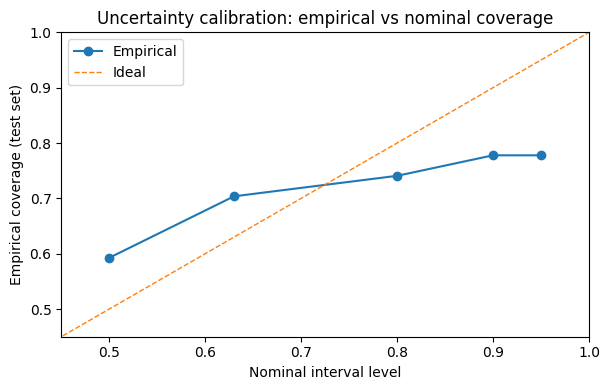

Saved: fig_calibration_coverage_curve.png
[Gaussian z] Level 0.63: empirical coverage = 0.704
[Gaussian z] Level 0.95: empirical coverage = 0.778
✓ Wrote feature_engineer.py


ElementProperty:   0%|          | 0/15 [00:00<?, ?it/s]

✓ Saved predictions → cte_predictions_XGB_NormalNLL.csv

=== PLOT SANITY TABLE (what is actually being plotted) ===
                                Formula       Exp        Mu         Sigma           Err  |Err|/Sigma
0                              Y3Al5O12  0.000009  0.000009  6.317222e-07 -1.553950e-07     0.245986
1             Y.6La.6Dy.6Ho.6Er.6Al5O12  0.000009  0.000009  6.405681e-07 -7.461600e-08     0.116484
2             Y.6Eu.6Dy.6Ho.6Er.6Al5O12  0.000009  0.000009  6.317222e-07  1.532090e-07     0.242526
3         Y.60Nd.60Dy.60Ho.60Er.6Al5O12  0.000009  0.000009  6.317222e-07  9.579800e-08     0.151646
4   Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12  0.000009  0.000009  6.317222e-07  1.232120e-07     0.195041
5      Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12  0.000009  0.000009  7.266067e-07  9.277600e-08     0.127684
6                              Y3Fe5O12  0.000011  0.000011  7.170017e-07 -1.103725e-07     0.153936
7                     Y3Fe2.50Al2.50O12  0.000010  0.000009  6.317222e-07 -6

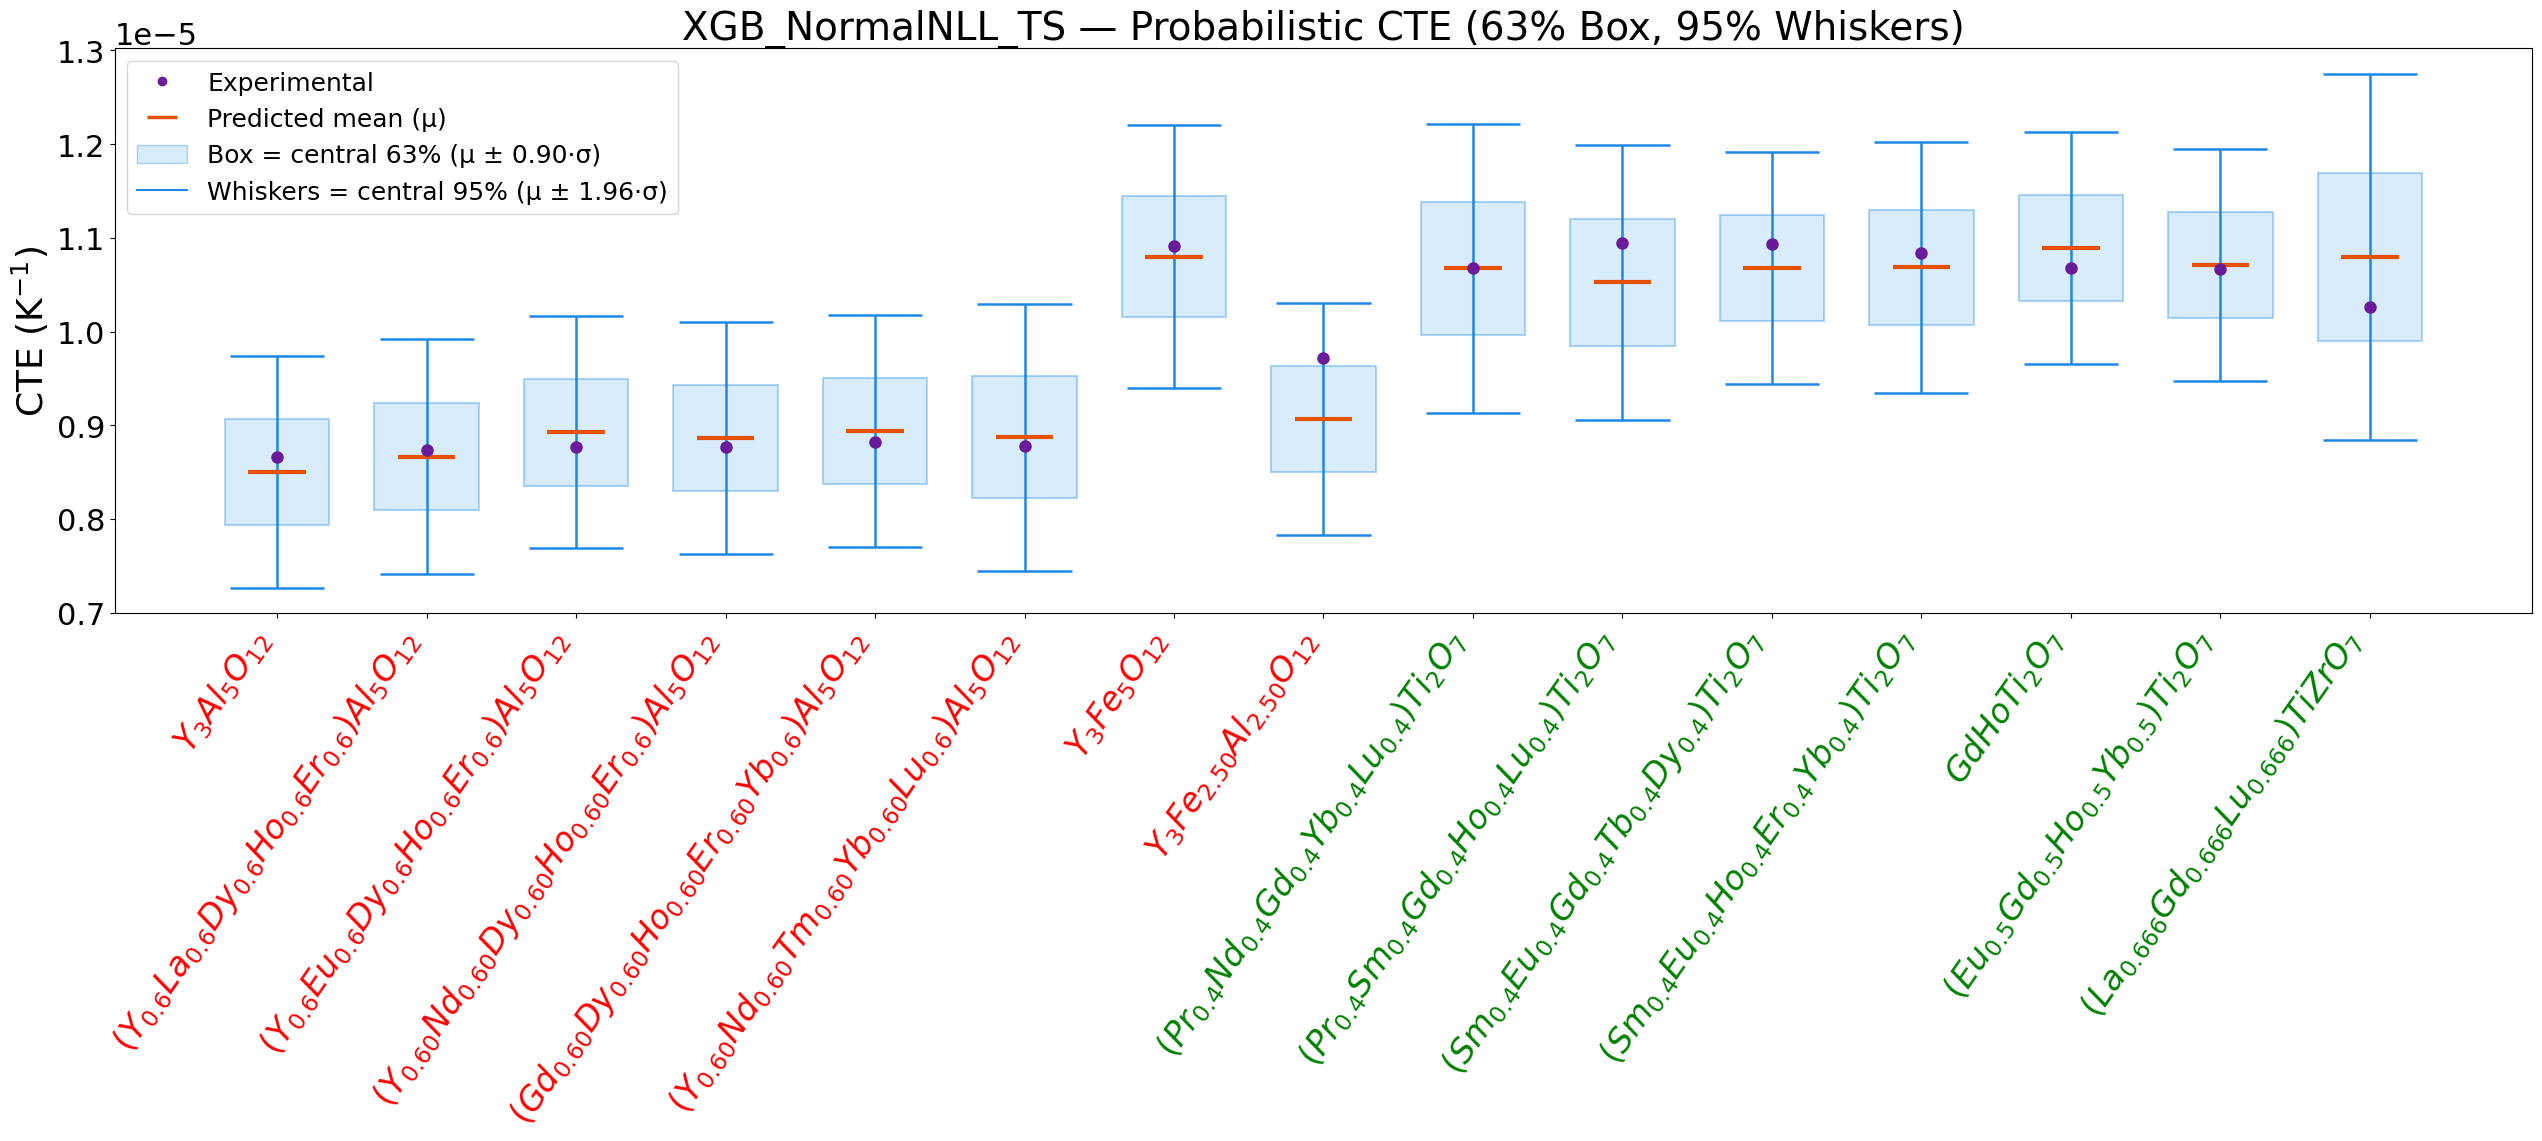

Saved readable plot → cte_prob_boxes_xgbn.png


In [ ]:
# XGB_NormalNLL two-stage
# Stage 1: μ via XGBoost (squarederror)
# Stage 2: logσ via custom NormalNLL objective
# σ calibrated on CALIB so that μ ± z95*(k·σ) hits target coverage
# Plot:
#   Box      = central 63% interval (μ ± 0.90σ)
#   Whiskers = central 95% interval (μ ± 1.96σ)

import os, re, json, textwrap, importlib.util, warnings, random
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from joblib import dump, load
from scipy.stats import norm

warnings.filterwarnings("ignore")

# HARD DETERMINISM / SEEDING
RANDOM_STATE = 42

def set_all_seeds(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_all_seeds(RANDOM_STATE)

# CONFIG
DO_TRAIN = True

ALLOW_OVERWRITE_MODELS = True

DATA_PATH = "composition_features_pymatgen.csv"
TARGET = "CTE Value"
DROP_COLS = ["Composition", "Composition_clean", "input",
             "normalized", "pretty_formula", "Unnamed: 0"]

TEST_SIZE = 0.2
CALIB_FRACTION = 0.2

# XGB params (seeded + deterministic)
XGB_PARAMS = dict(
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,

    # determinism
    seed=RANDOM_STATE,
    random_state=RANDOM_STATE,
    nthread=1,
    tree_method="hist",
)

ROUNDS_MU = 3000
EARLY_STOP = 100

# σ-head params
ROUNDS_S = 600
S_CLIP = (-5.0, 5.0)
XGB_PARAMS_SIG = dict(XGB_PARAMS, reg_lambda=2.0, reg_alpha=0.5)

# Calibration target
CALIB_COVERAGE = 0.95

# Sigma calibration & floor
CALIBRATE_SIGMA = True
SIGMA_FLOOR_FRAC = 0.05

# Artifacts
X_IMPUTER_PATH = "x_imputer_train.joblib"
X_TRAIN_FEATS  = "x_train_feature_names.json"
Y_SCALER_JOBLIB = "y_scaler.joblib"
MU_JSON  = "xgbn_mu.json"
S_JSON   = "xgbn_s.json"
CALIB_JSON = "prob_calibration.json"

# Inference I/O
PRED_CSV = "cte_predictions_XGB_NormalNLL.csv"

# Plot I/O
OUT_PNG  = "cte_prob_boxes_xgbn.png"
OUT_CALIB_CURVE = "fig_calibration_coverage_curve.png"


# Utilities
def load_dataframe(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"DATA_PATH not found: {path}")
    return pd.read_csv(path)

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    cols = (
        df.drop(columns=[c for c in [TARGET] + DROP_COLS if c in df.columns],
                errors="ignore")
          .select_dtypes(include=[np.number])
          .columns
          .tolist()
    )
    return cols

def empirical_coverage(y, mu, sig, level: float) -> float:
    alpha = 1.0 - level
    z = norm.ppf(1.0 - alpha/2.0)
    lo = mu - z * sig
    hi = mu + z * sig
    return float(np.mean((y >= lo) & (y <= hi)))

def plot_coverage_curve(y, mu, sig, out_png=OUT_CALIB_CURVE):
    levels = [0.50, 0.63, 0.80, 0.90, 0.95]
    cov = [empirical_coverage(y, mu, sig, L) for L in levels]

    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    ax.plot(levels, cov, marker="o", label="Empirical")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Ideal")
    ax.set_xlabel("Nominal interval level")
    ax.set_ylabel("Empirical coverage (test set)")
    ax.set_title("Uncertainty calibration: empirical vs nominal coverage")
    ax.set_xlim(0.45, 1.00)
    ax.set_ylim(0.45, 1.00)
    ax.legend()

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()
    print("Saved:", out_png)

    for L, C in zip(levels, cov):
        if np.isclose(L, 0.63) or np.isclose(L, 0.95):
            print(f"[Gaussian z] Level {L:.2f}: empirical coverage = {C:.3f}")

# custom objective for logσ
def obj_s(pred_s, dtrain):
    """
    NormalNLL objective for logσ:
      L = log σ^2 + r^2 / σ^2
      σ = exp(pred_s), r = y - μ
    """
    y  = dtrain.get_label()
    mu = dtrain.get_base_margin()
    r = y - mu
    invs2 = np.exp(-2.0 * pred_s)
    grad = 1.0 - (r * r) * invs2
    hess = 2.0 * (r * r) * invs2
    return grad, np.clip(hess, 1e-12, None)

# TRAIN
def train_two_stage() -> Dict[str, Any]:
    print("=== TRAIN: loading data ===")
    df = load_dataframe(DATA_PATH)
    if TARGET not in df.columns:
        raise ValueError(f"Target column '{TARGET}' not found in {DATA_PATH}")

    y_raw = df[TARGET].astype(float)
    feats = get_feature_columns(df)
    X_raw = df[feats].copy()

    imp = SimpleImputer(strategy="median")
    X_all = imp.fit_transform(X_raw)

    # save train artifacts
    dump(imp, X_IMPUTER_PATH)
    with open(X_TRAIN_FEATS, "w") as f:
        json.dump(feats, f)
    print(f"✓ Saved TRAIN imputer → {X_IMPUTER_PATH}")
    print(f"✓ Saved TRAIN feature list → {X_TRAIN_FEATS}")
    print(f"✓ #features = {len(feats)}")

    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y_raw.values.reshape(-1, 1)).ravel()
    dump(y_scaler, Y_SCALER_JOBLIB)
    print(f"✓ Saved y scaler → {Y_SCALER_JOBLIB}")

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_all, y_scaled, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    X_train_core, X_calib, y_train_core, y_calib = train_test_split(
        X_train_full, y_train_full, test_size=CALIB_FRACTION, random_state=RANDOM_STATE
    )

    inv_y = lambda z: y_scaler.inverse_transform(np.asarray(z).reshape(-1, 1)).ravel()

    # Stage 1: μ
    dtr  = xgb.DMatrix(X_train_core, label=y_train_core)
    dcal = xgb.DMatrix(X_calib,     label=y_calib)
    dte  = xgb.DMatrix(X_test,      label=y_test)

    mu_params = dict(XGB_PARAMS)
    mu_params["objective"] = "reg:squarederror"

    bst_mu = xgb.train(
        params=mu_params,
        dtrain=dtr,
        num_boost_round=ROUNDS_MU,
        evals=[(dtr, "train"), (dcal, "calib")],
        early_stopping_rounds=EARLY_STOP,
        verbose_eval=False,
    )

    mu_tr_sc  = bst_mu.predict(dtr)
    mu_cal_sc = bst_mu.predict(dcal)
    mu_te_sc  = bst_mu.predict(dte)

    mu_te      = inv_y(mu_te_sc)
    y_test_org = inv_y(y_test)

    rmse_plain = float(np.sqrt(mean_squared_error(y_test_org, mu_te)))
    r2_plain   = float(r2_score(y_test_org, mu_te))
    print(f"Plain XGB (μ): R²={r2_plain: .4f} | RMSE= {rmse_plain: .6e}")

    # Stage 2: σ (logσ)
    def fit_sigma_head(X_core, mu_core_sc, y_core_sc, X_eval, mu_eval_sc, y_eval_sc):
        dtr_s  = xgb.DMatrix(X_core, label=y_core_sc)
        dtr_s.set_base_margin(mu_core_sc)
        dval_s = xgb.DMatrix(X_eval, label=y_eval_sc)
        dval_s.set_base_margin(mu_eval_sc)

        bst_s = xgb.train(
            params=XGB_PARAMS_SIG,
            dtrain=dtr_s,
            num_boost_round=ROUNDS_S,
            obj=obj_s,
            evals=[(dtr_s, "train_s"), (dval_s, "eval_s")],
            verbose_eval=False,
        )
        return bst_s

    bst_s = fit_sigma_head(
        X_train_core, mu_tr_sc, y_train_core,
        X_calib,      mu_cal_sc, y_calib
    )

    # Predict σ on test (scaled space -> original space)
    dte_s = xgb.DMatrix(X_test)
    dte_s.set_base_margin(mu_te_sc)
    s_te_sc = np.clip(bst_s.predict(dte_s), S_CLIP[0], S_CLIP[1])
    sigma_te_sc = np.exp(s_te_sc)

    y_scale = float(y_scaler.scale_[0])
    sigma_te = sigma_te_sc * y_scale

    # Sigma floor + calibration on CALIB
    k_scale = 1.0
    sigma_floor = 0.0

    if CALIBRATE_SIGMA:
        mu_cal = inv_y(mu_cal_sc)
        y_cal_org = inv_y(y_calib)

        dcal_s = xgb.DMatrix(X_calib)
        dcal_s.set_base_margin(mu_cal_sc)
        s_cal_sc = np.clip(bst_s.predict(dcal_s), S_CLIP[0], S_CLIP[1])
        sigma_cal_sc = np.exp(s_cal_sc)
        sigma_cal = sigma_cal_sc * y_scale

        abs_res = np.abs(y_cal_org - mu_cal)

        sigma_floor = float(SIGMA_FLOOR_FRAC * np.nanmedian(abs_res))
        sigma_floor = sigma_floor if np.isfinite(sigma_floor) and sigma_floor > 0 else 1e-12

        sigma_cal = np.maximum(sigma_cal, sigma_floor)
        sigma_te  = np.maximum(sigma_te,  sigma_floor)

        tgt = float(CALIB_COVERAGE)
        z95 = float(norm.ppf((1.0 + tgt) / 2.0))
        u = abs_res / np.maximum(z95 * sigma_cal, 1e-30)
        u = u[np.isfinite(u)]
        k_scale = float(np.quantile(u, tgt))
        k_scale = max(k_scale, 1e-6)

        lo_c = mu_cal - z95 * (k_scale * sigma_cal)
        hi_c = mu_cal + z95 * (k_scale * sigma_cal)
        calib_cov = float(np.mean((y_cal_org >= lo_c) & (y_cal_org <= hi_c)))

        print(
            f"σ-calibration (CALIB): z95={z95:.3f}, k={k_scale:.3f}, "
            f"floor={sigma_floor:.3e}, CALIB_cov@{tgt:.2f}={calib_cov:.3f}"
        )

        sigma_te = sigma_te * k_scale

    z95 = float(norm.ppf((1.0 + CALIB_COVERAGE) / 2.0))
    lo = mu_te - z95 * sigma_te
    hi = mu_te + z95 * sigma_te
    coverage = float(np.mean((y_test_org >= lo) & (y_test_org <= hi)))
    print(
        f"Two-stage (μ+σ): R²={r2_plain: .4f} | RMSE= {rmse_plain: .6e} | "
        f"TEST Coverage@{CALIB_COVERAGE:.2f}≈{coverage:.3f}"
    )
    np.savez(
    "calibration_arrays_test.npz",
    y=np.asarray(y_test_org).ravel(),
    mu=np.asarray(mu_te).ravel(),
    sig=np.asarray(sigma_te).ravel(),
)
    print("Saved calibration arrays → calibration_arrays_test.npz")

    if (not ALLOW_OVERWRITE_MODELS) and (os.path.exists(MU_JSON) or os.path.exists(S_JSON)):
        raise RuntimeError(
            "Model files exist and ALLOW_OVERWRITE_MODELS=False. "
            "Set DO_TRAIN=False or allow overwrite intentionally."
        )

    bst_mu.save_model(MU_JSON)
    bst_s.save_model(S_JSON)
    with open(CALIB_JSON, "w") as f:
        json.dump(
            {
                "k_scale": k_scale,
                "calib_coverage": CALIB_COVERAGE,
                "sigma_floor": sigma_floor,
                "random_state": RANDOM_STATE,
            },
            f,
        )

    print(f"✓ Saved boosters → {MU_JSON}, {S_JSON}")
    print(f"✓ Saved sigma calibration → {CALIB_JSON}")

    return {
        "y_test_org": y_test_org,
        "mu_te": mu_te,
        "sigma_te": sigma_te,
    }
# Write featurizer
def write_featurizer():
    fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            try:
                radius = el.ionic_radii.get(ox_state, None) if ox_state is not None else None
            except Exception:
                radius = None
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)

        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid:
            return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for f, r in zip(fracs, radii))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None

        # mass heterogeneity (exclude O)
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s != "O"]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s != "O"]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None

        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [_compute_ionic_stats(f) for f in f_norm]
    ion = pd.DataFrame(
        ion,
        columns=[
            "Avg Ionic Radius (Å)",
            "Ionic Size Mismatch (%)",
            "Atomic Mass Diff (%)",
        ],
    )
    base = pd.concat([base, ion], axis=1)
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
    with open("feature_engineer.py", "w") as f:
        f.write(textwrap.dedent(fe_code))
    print("✓ Wrote feature_engineer.py")

# INFERENCE
def infer_xgb_normalnll(formulas: List[str]) -> pd.DataFrame:
    if not (os.path.exists(MU_JSON) and os.path.exists(S_JSON)):
        raise FileNotFoundError("Missing trained model JSONs. Train first or provide saved models.")
    if not (os.path.exists(X_IMPUTER_PATH) and os.path.exists(X_TRAIN_FEATS) and os.path.exists(Y_SCALER_JOBLIB)):
        raise FileNotFoundError("Missing train artifacts (imputer/feature list/y_scaler). Train first.")

    # load featurizer
    spec = importlib.util.spec_from_file_location("feature_engineer", "feature_engineer.py")
    fe = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(fe)
    X_full = fe.build_feature_matrix(formulas)

    imp = load(X_IMPUTER_PATH)
    with open(X_TRAIN_FEATS, "r") as f:
        feats = json.load(f)
    y_scaler = load(Y_SCALER_JOBLIB)

    # FORCE exact feature set + order
    for c in feats:
        if c not in X_full.columns:
            X_full[c] = np.nan
    X_imp = imp.transform(X_full[feats].values)

    bst_mu = xgb.Booster()
    bst_mu.load_model(MU_JSON)
    bst_s = xgb.Booster()
    bst_s.load_model(S_JSON)

    dmx = xgb.DMatrix(X_imp)
    mu_sc = bst_mu.predict(dmx)

    dmx_s = xgb.DMatrix(X_imp)
    dmx_s.set_base_margin(mu_sc)
    s_sc = np.clip(bst_s.predict(dmx_s), S_CLIP[0], S_CLIP[1])
    sigma_sc = np.exp(s_sc)

    mu = y_scaler.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
    sigma = sigma_sc * float(y_scaler.scale_[0])

    # load calibration
    k_scale = 1.0
    sigma_floor = 0.0
    if os.path.exists(CALIB_JSON):
        with open(CALIB_JSON, "r") as f:
            cj = json.load(f)
        k_scale = float(cj.get("k_scale", 1.0))
        sigma_floor = float(cj.get("sigma_floor", 0.0))

    if sigma_floor and np.isfinite(sigma_floor):
        sigma = np.maximum(sigma, sigma_floor)
    sigma = np.maximum(sigma * k_scale, 1e-12)

    out = pd.DataFrame(
        {
            "Formula": np.asarray(formulas),
            "XGB_NormalNLL_TS_mean": mu,
            "XGB_NormalNLL_TS_std": sigma,
        }
    )
    out.to_csv(PRED_CSV, index=False)
    print(f"✓ Saved predictions → {PRED_CSV}")
    return out

# EXP data + plot order
experimental_data = {
    "Y3Al5O12": 8.660000000e-6,
    "Y.6La.6Dy.6Ho.6Er.6Al5O12": 8.740000000e-6,
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12": 8.770000000e-6,
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12": 8.770000000e-6,
    "Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12": 8.820000000e-6,
    "Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12": 8.780000000e-6,
    "Y3Fe5O12": 1.091000000e-5,
    "Y3Fe2.50Al2.50O12": 9.720000000e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 1.068328000e-5,
    "Pr.4Sm.4Gd.4Ho.4Lu.4Ti2O7": 1.094065000e-5,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 1.093496000e-5,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 1.083446000e-5,
    "GdHoTi2O7": 1.068365000e-5,
    "Eu0.5Gd0.5Ho0.5Yb0.5Ti2O7": 1.066338000e-5,
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
}

plot_order = [
    "Y3Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12",
    "Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu.4Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "GdHoTi2O7",
    "Eu0.5Gd0.5Ho0.5Yb0.5Ti2O7",
    "La.666Gd.666Lu.666TiZrO7",
]

def _mixed_site_label(formula: str) -> str:
    """
    Keep mixed-site partial occupancies explicitly, but remove commas.
    Example:
      Pr.4Sm.4Gd.4Ho.4Lu.2Ti2O7 -> (Pr0.4Sm0.4Gd0.4Ho0.4Lu0.2)Ti2O7
    If there is no leading fractional run, returns the original formula.
    """
    tokens = re.findall(r'([A-Z][a-z]*)([0-9.]*)', formula)
    if not tokens:
        return formula

    elems, nums = [], []
    for el, num in tokens:
        elems.append(el)
        if num.strip() == "":
            nums.append(None)
        else:
            # ".4" -> "0.4"
            num_norm = ("0" + num) if num.startswith(".") else num
            nums.append(num_norm)

    i = 0
    while i < len(nums):
        n = nums[i]
        if n is None:
            break
        try:
            if float(n) < 1.0:
                i += 1
                continue
        except Exception:
            break
        break

    if i == 0:
        return formula

    mixed = []
    for el, n in zip(elems[:i], nums[:i]):
        # n is fractional string like "0.4"
        mixed.append(f"{el}{n}")

    rest = []
    for el, n in zip(elems[i:], nums[i:]):
        if n is None or (isinstance(n, str) and n.strip() in ("", "1")):
            rest.append(f"{el}")
        else:
            rest.append(f"{el}{n}")

    return "(" + "".join(mixed) + ")" + "".join(rest)

def formula_to_mathtext(formula: str) -> str:
    """
    Convert label (including mixed-site parentheses) into Matplotlib mathtext
    with subscripts. Keeps decimals.
    Example:
      (Pr0.4Sm0.4Lu0.2)Ti2O7 -> $(Pr_{0.4}Sm_{0.4}Lu_{0.2})Ti_{2}O_{7}$
    """
    s = _mixed_site_label(formula)

    s = re.sub(
        r'(?<=[A-Za-z\)])([0-9]+(?:\.[0-9]+)?)',
        r'_{\1}',
        s
    )
    return f"${s}$"


def plot_prob_boxes(pred_csv=PRED_CSV, out_png=OUT_PNG):
    if not os.path.exists(pred_csv):
        raise FileNotFoundError(pred_csv)
    df = pd.read_csv(pred_csv)

    mu_col = "XGB_NormalNLL_TS_mean"
    sd_col = "XGB_NormalNLL_TS_std"
    if mu_col not in df.columns or sd_col not in df.columns:
        raise ValueError("Expected probabilistic columns not found in predictions CSV.")

    df = df[df["Formula"].isin(experimental_data.keys())].copy()
    df["Experimental"] = df["Formula"].map(experimental_data)

    idx = {f: i for i, f in enumerate(plot_order)}
    df["__ord__"] = df["Formula"].map(idx)
    df.sort_values("__ord__", inplace=True, kind="mergesort")
    df.drop(columns="__ord__", inplace=True)

    labels = [formula_to_mathtext(f) for f in df["Formula"].tolist()]
    mu  = df[mu_col].to_numpy(dtype=float)
    sd  = df[sd_col].to_numpy(dtype=float)
    yexp = df["Experimental"].to_numpy(dtype=float)

    sanity = pd.DataFrame({
        "Formula": df["Formula"].values,
        "Exp": yexp,
        "Mu": mu,
        "Sigma": sd,
        "Err": (mu - yexp),
    })
    sanity["|Err|/Sigma"] = np.abs(sanity["Err"]) / np.maximum(sanity["Sigma"], 1e-30)
    print("\n=== PLOT SANITY TABLE (what is actually being plotted) ===")
    print(sanity.to_string(index=True))

    pos = np.isfinite(sd) & (sd > 0)
    fallback = np.nanmedian(sd[pos]) if np.any(pos) else 1e-12
    sd = np.where(pos, sd, fallback)

    x = np.arange(len(labels))
    box_half = 0.35

    BOX_COVERAGE = 0.63
    WHISKER_COVERAGE = 0.95
    z_box   = norm.ppf((1.0 + BOX_COVERAGE) / 2.0)      # ~0.90
    z_whisk = norm.ppf((1.0 + WHISKER_COVERAGE) / 2.0)  # ~1.96

    plt.rcParams.update({
        "font.size": 26,
        "xtick.labelsize": 24,
        "ytick.labelsize": 22,
        "axes.labelsize": 26,
        "axes.titlesize": 28,
        "legend.fontsize": 18,
    })

    plt.figure(figsize=(26, 12))
    ax = plt.gca()

    for i, (m, s) in enumerate(zip(mu, sd)):
        low_box, high_box = m - z_box * s,   m + z_box * s
        low_wh,  high_wh  = m - z_whisk * s, m + z_whisk * s

        rect = Rectangle(
            (i - box_half, low_box),
            2 * box_half,
            (high_box - low_box),
            facecolor="#90CAF9",
            edgecolor="#1E88E5",
            alpha=0.35,
            linewidth=1.5,
        )
        ax.add_patch(rect)

        ax.vlines(i, low_wh, high_wh, linewidth=1.8, color="#1E88E5")
        cap_w = box_half * 0.9
        ax.hlines([low_wh, high_wh], i - cap_w, i + cap_w,
                  linewidth=1.8, color="#1E88E5")

        # μ tick
        mean_half = box_half * 0.55
        ax.hlines(m, i - mean_half, i + mean_half, color="#E65100", linewidth=3.0)

    ax.plot(x, yexp, "o", markersize=8, color="#6A1B9A", label="Experimental")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right")

    for tick_text, raw_formula in zip(ax.get_xticklabels(),
                                     df["Formula"].tolist()):

        if "O12" in raw_formula:
            tick_text.set_color("red")

        elif "O7" in raw_formula:
            tick_text.set_color("green")

    ax.set_ylabel(r"CTE (K$^{-1}$)")

    y_min = min(np.min(yexp), np.min(mu - z_whisk * sd))
    y_max = max(np.max(yexp), np.max(mu + z_whisk * sd))
    pad = 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - pad, y_max + pad)

    exp_dot, = ax.plot([], [], "o", color="#6A1B9A", label="Experimental")
    mean_tick, = ax.plot(
    [], [],
    marker="_",
    linestyle="none",
    color="#E65100",
    markersize=22,
    markeredgewidth=2.5,
    label="Predicted mean (μ)"
)

    box_patch = Rectangle(
        (0, 0), 1, 1,
        facecolor="#90CAF9",
        edgecolor="#1E88E5",
        alpha=0.35,
        label=f"Box = central 63% (μ ± {z_box:.2f}·σ)",
    )
    whisker_line, = ax.plot(
        [], [], color="#1E88E5",
        label=f"Whiskers = central 95% (μ ± {z_whisk:.2f}·σ)",
    )
    ax.legend(handles=[exp_dot, mean_tick, box_patch, whisker_line],
              loc="upper left", frameon=True)

    ax.set_title("XGB_NormalNLL_TS — Probabilistic CTE (63% Box, 95% Whiskers)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved readable plot → {out_png}")

# MAIN
NEW_FORMULAS = plot_order

def write_and_run():
    write_featurizer()
    _ = infer_xgb_normalnll(NEW_FORMULAS)
    plot_prob_boxes(PRED_CSV, OUT_PNG)

train_out = None
if DO_TRAIN:
    train_out = train_two_stage()
    plot_coverage_curve(
        y=np.asarray(train_out["y_test_org"]).ravel(),
        mu=np.asarray(train_out["mu_te"]).ravel(),
        sig=np.asarray(train_out["sigma_te"]).ravel(),
        out_png=OUT_CALIB_CURVE
    )

write_and_run()


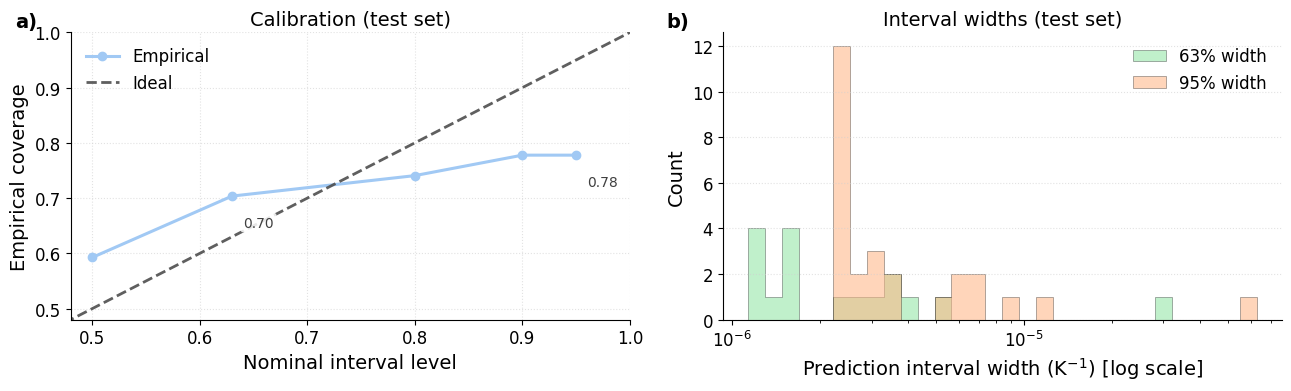

Saved: fig_uncertainty_diagnostics_2panel.png
Also saved: fig_calibration_coverage_curve.png, fig_interval_width_hist.png


In [ ]:
# PLOTTING ONLY: 2-panel uncertainty diagnostics figure
#   (a) Coverage curve (empirical vs nominal)
#   (b) Interval width distribution (log-x so bulk is visible)
# - No training
# - Loads y, mu, sig from an .npz

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm

# Style
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

PASTEL = {
    "emp":  "#A1C9F4",
    "ideal":"#4D4D4D",
    "w63":  "#8DE5A1",
    "w95":  "#FFB482",
    "grid": "#D0D0D0",
}

NPZ_PATH = "calibration_arrays_test.npz"

# Helpers
def load_npz(npz_path: str):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(
            f"Could not find {npz_path}. Either create it, or set y/mu/sig directly."
        )
    d = np.load(npz_path)
    y = np.asarray(d["y"]).ravel()
    mu = np.asarray(d["mu"]).ravel()
    sig = np.asarray(d["sig"]).ravel()
    return y, mu, sig

def empirical_coverage(y, mu, sig, level: float) -> float:
    alpha = 1.0 - level
    z = norm.ppf(1.0 - alpha / 2.0)
    lo = mu - z * sig
    hi = mu + z * sig
    return float(np.mean((y >= lo) & (y <= hi)))

def interval_width(sig, level: float) -> np.ndarray:
    alpha = 1.0 - level
    z = norm.ppf(1.0 - alpha / 2.0)
    return 2.0 * z * sig

def log_bins(x, nbins=30):
    """Log-spaced bins for positive data."""
    x = x[np.isfinite(x) & (x > 0)]
    lo = np.min(x)
    hi = np.max(x)
    return np.logspace(np.log10(lo), np.log10(hi), nbins + 1)

# Single 2-panel figure
def plot_uncertainty_2panel(
    y, mu, sig,
    cov_levels=(0.50, 0.63, 0.80, 0.90, 0.95),
    width_levels=(0.63, 0.95),
    out_png="fig_uncertainty_diagnostics_2panel.png",
    separate_panels=True,
):
    cov_levels = list(cov_levels)
    cov = [empirical_coverage(y, mu, sig, L) for L in cov_levels]

    widths = {}
    for L in width_levels:
        w = interval_width(sig, L)
        w = w[np.isfinite(w) & (w > 0)]
        widths[L] = w

    fig, axs = plt.subplots(1, 2, figsize=(13.2, 4.2))
    ax0, ax1 = axs

    # (a) Coverage curve
    ax0.plot(
        cov_levels, cov,
        marker="o", linewidth=2.2,
        label="Empirical", color=PASTEL["emp"]
    )
    ax0.plot(
        [0, 1], [0, 1],
        linestyle="--", linewidth=2.0,
        label="Ideal", color=PASTEL["ideal"], alpha=0.9
    )

    ax0.set_xlabel("Nominal interval level")
    ax0.set_ylabel("Empirical coverage")
    ax0.set_title("Calibration (test set)")

    ax0.set_xlim(min(cov_levels) - 0.02, 1.0)
    ax0.set_ylim(min(cov_levels) - 0.02, 1.0)

    ax0.grid(True, linestyle=":", linewidth=0.8, alpha=0.6, color=PASTEL["grid"])
    ax0.spines["top"].set_visible(False)
    ax0.spines["right"].set_visible(False)
    ax0.legend(frameon=False, loc="upper left")

    for L_anno in [0.63, 0.95]:
        if any(np.isclose(L_anno, np.array(cov_levels))):
            i = int(np.where(np.isclose(np.array(cov_levels), L_anno))[0][0])
            ax0.annotate(
                f"{cov[i]:.2f}",
                xy=(cov_levels[i], cov[i]),
                xytext=(8, -14),
                textcoords="offset points",
                ha="left", va="top",
                fontsize=10,
                color="0.25",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85)
            )

    ax0.text(-0.10, 1.02, "a)", transform=ax0.transAxes, fontsize=14, fontweight="bold")

    # (b) Interval width distribution (LOG-X)
    all_w = np.concatenate([widths[L] for L in width_levels])
    bins = log_bins(all_w, nbins=30)

    for L in width_levels:
        color = PASTEL["w63"] if np.isclose(L, 0.63) else PASTEL["w95"]
        ax1.hist(
            widths[L],
            bins=bins,
            histtype="stepfilled",
            alpha=0.55,
            edgecolor="black",
            linewidth=0.4,
            label=f"{int(round(L*100))}% width",
            color=color
        )

    ax1.set_xscale("log")
    ax1.set_xlabel(r"Prediction interval width (K$^{-1}$) [log scale]")
    ax1.set_ylabel("Count")
    ax1.set_title("Interval widths (test set)")

    ax1.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.6, color=PASTEL["grid"])
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.legend(frameon=False, loc="upper right")

    ax1.text(-0.10, 1.02, "b)", transform=ax1.transAxes, fontsize=14, fontweight="bold")

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()
    print("Saved:", out_png)

    if separate_panels:
        fig_a, axa = plt.subplots(figsize=(6.5, 3.8))
        axa.plot(cov_levels, cov, marker="o", linewidth=2.2, label="Empirical", color=PASTEL["emp"])
        axa.plot([0, 1], [0, 1], "--", linewidth=2.0, label="Ideal", color=PASTEL["ideal"], alpha=0.9)
        axa.set_xlabel("Nominal interval level")
        axa.set_ylabel("Empirical coverage")
        axa.set_title("Calibration (test set)")
        axa.set_xlim(min(cov_levels) - 0.02, 1.0)
        axa.set_ylim(min(cov_levels) - 0.02, 1.0)
        axa.grid(True, linestyle=":", linewidth=0.8, alpha=0.6, color=PASTEL["grid"])
        axa.spines["top"].set_visible(False)
        axa.spines["right"].set_visible(False)
        axa.legend(frameon=False, loc="upper left")
        fig_a.tight_layout()
        fig_a.savefig("fig_calibration_coverage_curve.png", dpi=300)
        plt.close(fig_a)

        fig_b, axb = plt.subplots(figsize=(6.5, 3.8))
        for L in width_levels:
            color = PASTEL["w63"] if np.isclose(L, 0.63) else PASTEL["w95"]
            axb.hist(widths[L], bins=bins, histtype="stepfilled", alpha=0.55,
                     edgecolor="black", linewidth=0.4, label=f"{int(round(L*100))}% width", color=color)
        axb.set_xscale("log")
        axb.set_xlabel(r"Prediction interval width (K$^{-1}$) [log scale]")
        axb.set_ylabel("Count")
        axb.set_title("Interval widths (test set)")
        axb.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.6, color=PASTEL["grid"])
        axb.spines["top"].set_visible(False)
        axb.spines["right"].set_visible(False)
        axb.legend(frameon=False, loc="upper right")
        fig_b.tight_layout()
        fig_b.savefig("fig_interval_width_hist.png", dpi=300)
        plt.close(fig_b)

        print("Also saved: fig_calibration_coverage_curve.png, fig_interval_width_hist.png")


if __name__ == "__main__":
    y, mu, sig = load_npz(NPZ_PATH)
    plot_uncertainty_2panel(
        y, mu, sig,
        cov_levels=(0.50, 0.63, 0.80, 0.90, 0.95),
        width_levels=(0.63, 0.95),
        out_png="fig_uncertainty_diagnostics_2panel.png",
        separate_panels=True,
    )


In [ ]:
# SHAP for Two-Stage Probabilistic Model (Top-15 Only)
# Outputs:
#   shap_mu_beeswarm_top15.png
#   shap_mu_bar_top15.png
#   shap_mu_importance.csv
#   shap_sigma_beeswarm_top15.png
#   shap_sigma_bar_top15.png
#   shap_sigma_importance.csv


import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import xgboost as xgb
from joblib import load

warnings.filterwarnings("ignore")

SHAP_SAMPLE_N   = 2000
BACKGROUND_N    = 200
RANDOM_STATE    = 42
TOP_FEATURES    = 15
PCTL_XLIM_MU    = 99.5
PCTL_XLIM_SIGMA = 99.5

SHAP_CMAP = "coolwarm"


mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "axes.titlesize": 32,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26,
    "axes.titlepad": 12,
})


def _load_snapshot():
    imp = load(X_IMPUTER_PATH)
    feats = json.load(open(X_TRAIN_FEATS, "r"))
    y_scaler = load(Y_SCALER_JOBLIB)
    return imp, feats, y_scaler


def _aligned_imputed_df(csv_path):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(csv_path)
    df = pd.read_csv(csv_path)
    imp, feats, _ = _load_snapshot()
    for c in feats:
        if c not in df.columns:
            df[c] = np.nan
    X = df[feats].copy()
    X_imp = imp.transform(X.values)
    return pd.DataFrame(X_imp, columns=feats)


def _maybe_sample(X):
    if SHAP_SAMPLE_N and len(X) > SHAP_SAMPLE_N:
        return X.sample(SHAP_SAMPLE_N, random_state=RANDOM_STATE)
    return X


def _tight_xlims_from_percentile(shap_vals, pct):
    abs_vals = np.abs(shap_vals).ravel()
    abs_vals = abs_vals[np.isfinite(abs_vals)]
    if abs_vals.size == 0:
        return (-1.0, 1.0)
    lim = float(np.nanpercentile(abs_vals, pct))
    if not np.isfinite(lim) or lim <= 0:
        lim = float(np.nanmax(abs_vals)) if np.isfinite(np.nanmax(abs_vals)) else 1e-8
    return (-lim, lim)

def _clean_feature_name(name: str) -> str:
    for t in ["MagpieData ", "MagpieData_", "MagpieData."]:
        name = name.replace(t, "")
    name = name.replace("_", " ")
    name = name.replace("Start Temp (°C)", "Start Temp (°C)")
    name = name.replace("End Temp (°C)", "End Temp (°C)")
    return name

def _clean_feature_names(names):
    return [_clean_feature_name(n) for n in names]


def _format_x_as_sci(ax):
    """Force consistent scientific-notation formatting like ×10^{-6} when needed."""
    fmt = mticker.ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.xaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2))
    ax.xaxis.get_offset_text().set_size(18)


def _bar_with_values(names, vals, fname, title, xlabel):
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    y = np.arange(len(names))
    ax.barh(y, vals)
    ax.set_yticks(y)
    ax.set_yticklabels(_clean_feature_names(names))
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    for yi, v in zip(y, vals):
        ax.text(v, yi, f"{v:.2e}", va="center", ha="left", fontsize=18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.5)

    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.close()
    print(f"✓ {fname}")


def _summary_beeswarm(shap_values, X_df, feature_names, out_png, xlim, xlabel):
    """
    Uses shap.summary_plot (more controllable than shap.plots.beeswarm),
    then applies consistent formatting.
    """
    import shap

    plt.figure(figsize=(8.8, 7.2))
    shap.summary_plot(
        shap_values,
        X_df,
        feature_names=feature_names,
        max_display=TOP_FEATURES,
        show=False,
        cmap=SHAP_CMAP,
        plot_size=None
    )

    ax = plt.gca()
    ax.axvline(0, color="#808080", linewidth=1.2, alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_title("")

    ax.set_xlim(*xlim)
    _format_x_as_sci(ax)

    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.35)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()
    print(f"✓ {out_png}  (xlim = {xlim})")


def run_shap_both():
    import shap

    X = _aligned_imputed_df(DATA_PATH)
    Xs = _maybe_sample(X)
    B  = Xs.sample(min(BACKGROUND_N, len(Xs)), random_state=RANDOM_STATE)

    bst_mu = xgb.Booster(); bst_mu.load_model(MU_JSON)
    bst_s  = xgb.Booster(); bst_s.load_model(S_JSON)
    _, _, y_scaler = _load_snapshot()

    def predict_mu_original(x_np):
        dmx = xgb.DMatrix(x_np)
        mu_sc = bst_mu.predict(dmx)
        return y_scaler.inverse_transform(mu_sc.reshape(-1, 1)).ravel()

    expl_mu = shap.Explainer(predict_mu_original, B, algorithm="permutation")
    exp_mu  = expl_mu(Xs)
    shap_mu = np.asarray(exp_mu.values)

    mu_mean_abs = np.nanmean(np.abs(shap_mu), axis=0)
    mu_df = pd.DataFrame({
        "feature": Xs.columns,
        "clean":   _clean_feature_names(Xs.columns),
        "mean_abs_shap": mu_mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)

    mu_df.to_csv("shap_mu_importance.csv", index=False)
    print("✓ shap_mu_importance.csv")

    top_mu = mu_df.head(TOP_FEATURES)
    idx_mu = top_mu.index.values
    Xs_mu = Xs.iloc[:, idx_mu]
    shap_mu_sub = shap_mu[:, idx_mu]
    xlim_mu = _tight_xlims_from_percentile(shap_mu_sub, PCTL_XLIM_MU)

    _summary_beeswarm(
        shap_values=shap_mu_sub,
        X_df=Xs_mu,
        feature_names=list(top_mu.clean),
        out_png="shap_mu_beeswarm_top15.png",
        xlim=xlim_mu,
        xlabel="SHAP value"
    )

    _bar_with_values(
        list(top_mu.clean),
        list(top_mu.mean_abs_shap),
        "shap_mu_bar_top15.png",
        "Top 15 mean |SHAP| (μ head)",
        "Mean |SHAP|"
    )

    def predict_log_sigma(x_np):
        dmx = xgb.DMatrix(x_np)
        mu_sc = bst_mu.predict(dmx)
        dmx_s = xgb.DMatrix(x_np, base_margin=mu_sc)
        return bst_s.predict(dmx_s)

    expl_s = shap.Explainer(predict_log_sigma, B, algorithm="permutation")
    exp_s  = expl_s(Xs)
    shap_s = np.asarray(exp_s.values)

    s_mean_abs = np.nanmean(np.abs(shap_s), axis=0)
    s_df = pd.DataFrame({
        "feature": Xs.columns,
        "clean":   _clean_feature_names(Xs.columns),
        "mean_abs_shap": s_mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)

    s_df.to_csv("shap_sigma_importance.csv", index=False)
    print("✓ shap_sigma_importance.csv")

    top_s = s_df.head(TOP_FEATURES)
    idx_s = top_s.index.values
    Xs_s = Xs.iloc[:, idx_s]
    shap_s_sub = shap_s[:, idx_s]
    xlim_sigma = _tight_xlims_from_percentile(shap_s_sub, PCTL_XLIM_SIGMA)

    _summary_beeswarm(
        shap_values=shap_s_sub,
        X_df=Xs_s,
        feature_names=list(top_s.clean),
        out_png="shap_sigma_beeswarm_top15.png",
        xlim=xlim_sigma,
        xlabel="SHAP value"
    )

    _bar_with_values(
        list(top_s.clean),
        list(top_s.mean_abs_shap),
        "shap_sigma_bar_top15.png",
        "Top 15 mean |SHAP| (σ head; log-space)",
        "Mean |SHAP|"
    )


run_shap_both()


PermutationExplainer explainer: 135it [01:22,  1.63it/s]


✓ shap_mu_importance.csv
✓ shap_mu_beeswarm_top15.png  (xlim = (-2.3315502553201017e-06, 2.3315502553201017e-06))
✓ shap_mu_bar_top15.png


PermutationExplainer explainer: 135it [02:07,  1.03s/it]


✓ shap_sigma_importance.csv
✓ shap_sigma_beeswarm_top15.png  (xlim = (-0.9046974394738672, 0.9046974394738672))
✓ shap_sigma_bar_top15.png


# Additional Plots

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_first_existing(paths):
    for p in paths:
        if p and Path(p).exists():
            return str(Path(p))
    return None

CWD = Path(".")
DATA_CANDIDATES = [
    "CTE Value 10.xlsx",
    "normalized_compositions_output.csv",
    "composition_features_pymatgen.csv",
]

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 10,
})


In [ ]:
cte_xlsx = find_first_existing([CWD / "CTE Value 10.xlsx", CWD / "CTE_Value_10.xlsx"])
if cte_xlsx is None:
    raise FileNotFoundError("Could not find 'CTE Value 10.xlsx' in the notebook directory.")

df_raw = pd.read_excel(cte_xlsx)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    lower = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None

col_cte   = pick_col(df_raw, ["CTE Value", "CTE", "cte", "cte_value"])
col_start = pick_col(df_raw, ["Start Temp (°C)", "Start Temp", "T_start", "Start_Temp"])
col_end   = pick_col(df_raw, ["End Temp (°C)", "End Temp", "T_end", "End_Temp"])
col_comp  = pick_col(df_raw, ["Composition", "Formula", "composition", "formula"])

missing = [("CTE", col_cte), ("Start Temp", col_start), ("End Temp", col_end), ("Composition", col_comp)]
missing = [name for name, col in missing if col is None]
if missing:
    raise KeyError(f"Missing expected columns in Excel: {missing}. Available: {list(df_raw.columns)}")

df = df_raw.copy()
df[col_comp] = df[col_comp].astype(str).str.strip()
df[col_cte] = pd.to_numeric(df[col_cte], errors="coerce")
df[col_start] = pd.to_numeric(df[col_start], errors="coerce")
df[col_end] = pd.to_numeric(df[col_end], errors="coerce")

df = df.dropna(subset=[col_cte])
print("Rows:", len(df), "| Unique compositions:", df[col_comp].nunique())
print("CTE mean:", df[col_cte].mean(), "| std:", df[col_cte].std())
print("CTE min/max:", df[col_cte].min(), df[col_cte].max())
print("Start temp min/max:", df[col_start].min(), df[col_start].max())
print("End temp min/max:", df[col_end].min(), df[col_end].max())

Rows: 204 | Unique compositions: 188
CTE mean: 9.322205882352941e-06 | std: 4.1710955356184155e-06
CTE min/max: -6.2e-06 3.3e-05
Start temp min/max: 20 1400
End temp min/max: 25 1673


In [ ]:
# TWO HISTOGRAM

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12
})

PALETTE = ({
    "cte":   "#A1C9F4",
    "lower": "#A1C9F4",
    "upper": "#FFB482",
    "accent":"#8DE5A1",
    "line":  "#4D4D4D"
})
def freedman_diaconis_bins(x, min_bins=12, max_bins=60, fallback=30):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return min_bins
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return fallback
    bw = 2 * iqr * (x.size ** (-1/3))
    if not np.isfinite(bw) or bw <= 0:
        return fallback
    nb = int(np.ceil((x.max() - x.min()) / bw))
    return int(np.clip(nb, min_bins, max_bins))

def robust_xlim(x, lo_pct=0.5, hi_pct=99.0, pad_frac=0.05, fallback_pad=50.0):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (-1, 1)
    if x.size >= 5:
        lo, hi = np.percentile(x, [lo_pct, hi_pct])
    else:
        lo, hi = float(np.min(x)), float(np.max(x))
    if np.isfinite(hi - lo) and (hi - lo) > 0:
        pad = pad_frac * (hi - lo)
    else:
        pad = fallback_pad
    return (lo - pad, hi + pad)

def apply_clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)
    ax.tick_params(axis="both", which="major", labelsize=mpl.rcParams["xtick.labelsize"])

# CTE distribution

fig, ax = plt.subplots(figsize=(6.5, 3.8))

vals = df[col_cte].dropna().to_numpy().astype(float)
vals_plot = (vals * 1e6)
vals_plot = vals_plot[np.isfinite(vals_plot)]

x_label = r"CTE (10$^{-6}$ K$^{-1}$)"
bins_cte = freedman_diaconis_bins(vals_plot, min_bins=12, max_bins=60, fallback=30)

ax.hist(
    vals_plot,
    bins=bins_cte,
    color=PALETTE["cte"],
    edgecolor="white",
    linewidth=0.7,
    alpha=0.95
)

ax.set_xlabel(x_label, labelpad=6)
ax.set_ylabel("Count", labelpad=6)
ax.set_title("", pad=8, fontweight="normal")

ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.7, color=PALETTE["line"])
ax.annotate(
    "CTE = 0",
    xy=(0.0, 0.95), xycoords=("data", "axes fraction"),
    xytext=(6, 0), textcoords="offset points",
    ha="left", va="top",
    fontsize=9, alpha=0.85, color=PALETTE["line"]
)

apply_clean_axes(ax)

x0, x1 = robust_xlim(vals_plot, lo_pct=0.5, hi_pct=99.5, pad_frac=0.05, fallback_pad=1.0)
ax.set_xlim(x0, x1)

out1 = "fig_dataset_cte_hist.png"
fig.tight_layout()
fig.savefig(out1, dpi=300)
plt.show()
print("Saved:", out1)

# Temperature bounds distribution

fig, ax = plt.subplots(figsize=(6.5, 3.8))

vals_lo = df[col_start].dropna().to_numpy().astype(float)
vals_hi = df[col_end].dropna().to_numpy().astype(float)

vals_lo = vals_lo[np.isfinite(vals_lo)]
vals_hi = vals_hi[np.isfinite(vals_hi)]
all_vals = np.concatenate([vals_lo, vals_hi])
all_vals = all_vals[np.isfinite(all_vals)]

x0, x1 = robust_xlim(all_vals, lo_pct=0.5, hi_pct=99.0, pad_frac=0.05, fallback_pad=50.0)
x0 = min(x0, -50.0)
ax.set_xlim(x0, x1)

main_vals = all_vals[(all_vals >= x0) & (all_vals <= x1)]
bins_temp = freedman_diaconis_bins(main_vals, min_bins=12, max_bins=60, fallback=30)
bins_edges = np.histogram_bin_edges(main_vals, bins=bins_temp)

ax.hist(
    vals_lo,
    bins=bins_edges,
    histtype="step",
    linewidth=2.0,
    color=PALETTE["lower"],
    label="Lower bound (°C)"
)
ax.hist(
    vals_hi,
    bins=bins_edges,
    histtype="step",
    linewidth=2.0,
    color=PALETTE["upper"],
    label="Upper bound (°C)"
)

ax.set_title("", pad=8, fontweight="normal")
ax.set_xlabel("Temperature (°C)", labelpad=6)
ax.set_ylabel("Count", labelpad=6)

apply_clean_axes(ax)

ax.legend(
    loc="upper right",
    frameon=False,
    handlelength=2.8,
    borderaxespad=0.8
)

true_min, true_max = float(np.min(all_vals)), float(np.max(all_vals))
ax.text(
    0.95, 0.7,
    f"Full range: [{true_min:.0f}, {true_max:.0f}] °C",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9, alpha=0.85, color=PALETTE["line"]
)

tail = vals_hi[vals_hi > x1]
if tail.size > 0:
    ax_in = ax.inset_axes([0.62, 0.55, 0.35, 0.35])

    nb_tail = int(np.clip(tail.size, 5, 12))
    bins_tail = np.histogram_bin_edges(tail, bins=nb_tail)

    ax_in.hist(
        tail,
        bins=bins_tail,
        histtype="step",
        linewidth=1.6,
        color=PALETTE["upper"]
    )

    ax_in.set_title(f"Upper-bound tail (>{x1:.0f} °C)", fontsize=9, pad=2)
    ax_in.tick_params(axis="both", which="major", labelsize=8)

    ax_in.spines["top"].set_visible(False)
    ax_in.spines["right"].set_visible(False)
    ax_in.spines["left"].set_linewidth(0.8)
    ax_in.spines["bottom"].set_linewidth(0.8)
    ax_in.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.25)

    ax_in.set_xlim(float(np.min(tail)), float(np.max(tail)) * 1.05)
    ax_in.text(
        0.02, 0.95, f"n={tail.size}",
        transform=ax_in.transAxes,
        ha="left", va="top",
        fontsize=8, alpha=0.85, color=PALETTE["line"]
    )

out2 = "fig_dataset_temp_bounds_hist.png"
fig.tight_layout()
fig.savefig(out2, dpi=300)
plt.show()
print("Saved:", out2)


In [ ]:
# FULL MODEL ZOO + XGB_NormalNLL_TS
# Uses ONE shared split (train/calib/test) saved to disk
# Trains baseline model zoo on that split
# Trains XGB_NormalNLL_TS (two-stage μ+σ) on that SAME split
# Computes comparable metrics for all models
# Saves:
#     results_models.joblib
#     table_benchmark_shared_split.csv
#     cte_predictions_all_models.csv   (y_true + each model's yhat on TEST)
#     3 metric bar plots (MAE/RMSE/R²)

import warnings, os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import dump
from typing import Tuple, Dict, Any

from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, TheilSenRegressor,
    TweedieRegressor, QuantileRegressor
)
from sklearn.svm import SVR, NuSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import norm

warnings.filterwarnings("ignore")

# Config
DATA_PATH = "composition_features_pymatgen.csv"
TARGET = "CTE Value"
SELECTED_FEATS_FILE = "selected_features.txt"

RESULTS_JOBLIB = "results_models.joblib"
Y_SCALER_JOBLIB = "y_scaler.joblib"
USE_Y_SCALER = True

DROP_COLS = ["Composition", "Composition_clean", "input", "normalized", "pretty_formula", "Unnamed: 0"]

SPLIT_FILE = "cte_shared_split_v1.npz"
TEST_SIZE = 0.20
CALIB_FRACTION = 0.20
RANDOM_STATE = 42

S_CLIP = (-5.0, 5.0)
CALIB_COVERAGE = 0.95
SIGMA_FLOOR_FRAC = 0.05

xgb_available = lgb_available = cat_available = False
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    lgb_available = False

try:
    from catboost import CatBoostRegressor
    cat_available = True
except Exception:
    cat_available = False

# Utility: shared split
def get_or_make_shared_split(n, split_file=SPLIT_FILE,
                             test_size=TEST_SIZE, calib_fraction=CALIB_FRACTION,
                             seed=RANDOM_STATE):
    if os.path.exists(split_file):
        z = np.load(split_file)
        print(f"✓ Loaded shared split → {split_file}")
        return z["train_idx"], z["calib_idx"], z["test_idx"]

    rng = np.random.RandomState(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_test = int(round(test_size * n))
    test_idx = idx[:n_test]
    train_full_idx = idx[n_test:]

    n_calib = int(round(calib_fraction * len(train_full_idx)))
    calib_idx = train_full_idx[:n_calib]
    train_idx = train_full_idx[n_calib:]

    np.savez(split_file, train_idx=train_idx, calib_idx=calib_idx, test_idx=test_idx)
    print(f"✓ Saved shared split → {split_file}")
    print(f"Sizes: train={len(train_idx)}, calib={len(calib_idx)}, test={len(test_idx)}")
    return train_idx, calib_idx, test_idx

# Helpers: pipelines
def scaled_model(estimator) -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

def tree_model(estimator) -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("model", estimator),
    ])

# Metrics
def inverse_target(z: np.ndarray, y_scaler: StandardScaler, use_scaler: bool) -> np.ndarray:
    z = np.asarray(z).reshape(-1, 1)
    if use_scaler:
        return y_scaler.inverse_transform(z).ravel()
    return z.ravel()

def mse_rmse_r2(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    return float(mse), rmse, r2

def mae(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if np.any(m) else np.nan

# Load data
df = pd.read_csv(DATA_PATH)
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")
y_raw = df[TARGET].astype(float)

def get_feature_columns(df: pd.DataFrame) -> list:
    if os.path.exists(SELECTED_FEATS_FILE):
        with open(SELECTED_FEATS_FILE, "r") as f:
            feats = [ln.strip() for ln in f if ln.strip()]
        missing = [c for c in feats if c not in df.columns]
        if missing:
            print(f"[INFO] {len(missing)} selected features missing from CSV. Examples: {missing[:6]}")
            for c in missing:
                df[c] = np.nan
        return feats
    return df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns], errors="ignore")\
             .select_dtypes(include=np.number).columns.tolist()

feature_cols = get_feature_columns(df)
X = df[feature_cols].copy()

mask = y_raw.notna()
X = X.loc[mask].reset_index(drop=True)
y_raw = y_raw.loc[mask].reset_index(drop=True)

print(f"X shape: {X.shape} | #features: {len(feature_cols)}")

if USE_Y_SCALER:
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y_raw.values.reshape(-1, 1)).ravel()
    dump(y_scaler, Y_SCALER_JOBLIB)
    print(f"✓ Saved target scaler → {Y_SCALER_JOBLIB}")
else:
    y_scaler = None
    y_scaled = y_raw.values

# Shared split indices
train_idx, calib_idx, test_idx = get_or_make_shared_split(len(X))

X_train = X.iloc[train_idx]
X_calib = X.iloc[calib_idx]
X_test  = X.iloc[test_idx]

y_train = y_scaled[train_idx]
y_calib = y_scaled[calib_idx]
y_test  = y_scaled[test_idx]

y_test_org = inverse_target(y_test, y_scaler, USE_Y_SCALER) if USE_Y_SCALER else y_test

print("Split shapes:", X_train.shape, X_calib.shape, X_test.shape)

# Build model zoo
models = {
    # Trees
    "RandomForest": tree_model(RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=0, n_jobs=-1)),
    "GradientBoosting": tree_model(GradientBoostingRegressor(random_state=0)),
    "ExtraTrees": tree_model(ExtraTreesRegressor(n_estimators=600, random_state=0, n_jobs=-1)),
    "DecisionTree": tree_model(DecisionTreeRegressor(random_state=0)),
    "HistGBR": tree_model(HistGradientBoostingRegressor(random_state=0)),
    "AdaBoost": tree_model(AdaBoostRegressor(n_estimators=300, random_state=0)),
    "Bagging_RF": tree_model(BaggingRegressor(
        estimator=RandomForestRegressor(n_estimators=80, random_state=0, n_jobs=-1),
        n_estimators=20, random_state=0
    )),
    # Linear & regularized
    "Ridge": scaled_model(Ridge(alpha=1.0, random_state=0)),
    "Lasso": scaled_model(Lasso(alpha=1e-3, random_state=0, max_iter=10000)),
    "ElasticNet": scaled_model(ElasticNet(alpha=1e-3, l1_ratio=0.5, random_state=0, max_iter=10000)),
    "BayesianRidge": scaled_model(BayesianRidge()),
    "Huber": scaled_model(HuberRegressor()),
    "TheilSen": scaled_model(TheilSenRegressor()),
    "Tweedie": scaled_model(TweedieRegressor(power=1, alpha=0.5)),
    "Quantile": scaled_model(QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs")),
    # SVM/KNN
    "SVR": scaled_model(SVR(C=10.0, epsilon=0.01, kernel="rbf")),
    "NuSVR": scaled_model(NuSVR(kernel="rbf", C=1.0, nu=0.5)),
    "KNN": scaled_model(KNeighborsRegressor(n_neighbors=7)),
    # Neural net
    "MLP": scaled_model(MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=0)),
    # Gaussian Process
    "GaussianProcess": scaled_model(GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        normalize_y=True, random_state=0
    )),
}

if xgb_available:
    models["XGBoost"] = tree_model(XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, tree_method="hist"
    ))
if lgb_available:
    models["LightGBM"] = tree_model(LGBMRegressor(
        n_estimators=800, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=0, n_jobs=-1
    ))
if cat_available:
    models["CatBoost"] = tree_model(CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6, random_seed=0, verbose=False
    ))

# Train & evaluate model zoo
results: Dict[str, Dict[str, Any]] = {}
pred_test_cols = {}

for name, mdl in models.items():
    try:
        mdl.fit(X_train, y_train)
        y_pred_sc = np.asarray(mdl.predict(X_test)).ravel()

        y_pred_org = inverse_target(y_pred_sc, y_scaler, USE_Y_SCALER) if USE_Y_SCALER else y_pred_sc
        mse, rmse, r2v = mse_rmse_r2(y_test_org, y_pred_org)

        results[name] = {"model": mdl, "MSE": mse, "RMSE": rmse, "R²": r2v, "MAE": mae(y_test_org, y_pred_org)}
        pred_test_cols[name] = y_pred_org

        print(f"{name:>15}: R²={r2v: .4f} | RMSE={rmse: .6e} | MAE={results[name]['MAE']: .6e}")
    except Exception as e:
        print(f"{name} failed: {e}")

# XGB_NormalNLL_TS
if not xgb_available:
    print("\n[WARN] xgboost not available; skipping XGB_NormalNLL_TS.")
else:
    XGB_PARAMS = dict(
        max_depth=6,
        eta=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="reg:squarederror",
    )
    XGB_PARAMS_SIG = dict(XGB_PARAMS)
    XGB_PARAMS_SIG.update(dict(reg_lambda=2.0, reg_alpha=0.5))
    XGB_PARAMS_SIG.pop("objective", None)

    def obj_s(pred_s, dtrain):
        y  = dtrain.get_label()
        mu = dtrain.get_base_margin()
        r = y - mu
        invs2 = np.exp(-2.0 * pred_s)
        grad = 1.0 - (r * r) * invs2
        hess = 2.0 * (r * r) * invs2
        return grad, np.clip(hess, 1e-12, None)

    imp_nll = SimpleImputer(strategy="median")
    Xtr_nll = imp_nll.fit_transform(X_train)
    Xca_nll = imp_nll.transform(X_calib)
    Xte_nll = imp_nll.transform(X_test)

    dtr  = xgb.DMatrix(Xtr_nll, label=y_train)
    dcal = xgb.DMatrix(Xca_nll, label=y_calib)
    dte  = xgb.DMatrix(Xte_nll, label=y_test)

    bst_mu = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtr,
        num_boost_round=3000,
        evals=[(dtr, "train"), (dcal, "calib")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    mu_tr_sc  = bst_mu.predict(dtr)
    mu_cal_sc = bst_mu.predict(dcal)
    mu_te_sc  = bst_mu.predict(dte)

    mu_te_org = inverse_target(mu_te_sc, y_scaler, USE_Y_SCALER) if USE_Y_SCALER else mu_te_sc

    dtr_s  = xgb.DMatrix(Xtr_nll, label=y_train); dtr_s.set_base_margin(mu_tr_sc)
    dcal_s = xgb.DMatrix(Xca_nll, label=y_calib); dcal_s.set_base_margin(mu_cal_sc)

    bst_s = xgb.train(
        params=XGB_PARAMS_SIG,
        dtrain=dtr_s,
        num_boost_round=600,
        obj=obj_s,
        evals=[(dtr_s, "train_s"), (dcal_s, "calib_s")],
        verbose_eval=False,
    )

    dte_s = xgb.DMatrix(Xte_nll); dte_s.set_base_margin(mu_te_sc)
    s_te_sc = np.clip(bst_s.predict(dte_s), S_CLIP[0], S_CLIP[1])
    sigma_te_sc = np.exp(s_te_sc)

    if USE_Y_SCALER:
        y_scale = float(y_scaler.scale_[0])
    else:
        y_scale = 1.0
    sigma_te_org = sigma_te_sc * y_scale

    dcal_for_sig = xgb.DMatrix(Xca_nll); dcal_for_sig.set_base_margin(mu_cal_sc)
    s_cal_sc = np.clip(bst_s.predict(dcal_for_sig), S_CLIP[0], S_CLIP[1])
    sigma_cal_org = np.exp(s_cal_sc) * y_scale

    mu_cal_org = inverse_target(mu_cal_sc, y_scaler, USE_Y_SCALER) if USE_Y_SCALER else mu_cal_sc
    y_cal_org  = inverse_target(y_calib, y_scaler, USE_Y_SCALER) if USE_Y_SCALER else y_calib

    abs_res = np.abs(y_cal_org - mu_cal_org)
    sigma_floor = float(SIGMA_FLOOR_FRAC * np.nanmedian(abs_res))
    sigma_floor = sigma_floor if np.isfinite(sigma_floor) and sigma_floor > 0 else 1e-12

    sigma_cal_org = np.maximum(sigma_cal_org, sigma_floor)
    sigma_te_org  = np.maximum(sigma_te_org,  sigma_floor)

    z = abs_res / np.maximum(sigma_cal_org, 1e-30)
    z = z[np.isfinite(z)]
    gauss_q = float(norm.ppf((1.0 + CALIB_COVERAGE) / 2.0))
    q = float(np.quantile(z, CALIB_COVERAGE))
    k_scale = max(float(q / gauss_q), 1e-6)
    sigma_te_org *= k_scale

    mse, rmse, r2v = mse_rmse_r2(y_test_org, mu_te_org)
    mae_v = mae(y_test_org, mu_te_org)

    results["XGB_NormalNLL_TS"] = {
        "model": ("two_stage_xgb_normalnll", bst_mu, bst_s, imp_nll),
        "MSE": mse, "RMSE": rmse, "R²": r2v, "MAE": mae_v,
        "k_scale": k_scale, "sigma_floor": sigma_floor
    }
    pred_test_cols["XGB_NormalNLL_TS"] = mu_te_org

    print(f"{'XGB_NormalNLL_TS':>15}: R²={r2v: .4f} | RMSE={rmse: .6e} | MAE={mae_v: .6e} | (shared split)")

# Save results + tables + prediction CSV
dump(results, RESULTS_JOBLIB)
print(f"\n✓ Saved models + metrics → {RESULTS_JOBLIB}")

metrics_df = pd.DataFrame(results).T[["MAE", "RMSE", "MSE", "R²"]].sort_values("MAE", ascending=True)
bench_out = "table_benchmark_shared_split.csv"
metrics_df.to_csv(bench_out)
print(f"✓ Saved benchmark table → {bench_out}")

pred_out = "cte_predictions_all_models.csv"
pred_df = pd.DataFrame({"y_true": y_test_org})
for k, v in pred_test_cols.items():
    pred_df[k] = np.asarray(v).ravel()
pred_df.to_csv(pred_out, index=False)
print(f"✓ Saved test predictions → {pred_out}")

print("\n=== Top models by MAE (shared split) ===")
print(metrics_df.head(15))

# Plotting
def metric_bar(metric, out_png, higher_is_better=False, top_n=None):
    dfp = metrics_df.copy()
    dfp = dfp.sort_values(metric, ascending=not higher_is_better)
    if top_n is not None:
        dfp = dfp.head(top_n)
    dfp = dfp.sort_values(metric, ascending=not higher_is_better)

    fig, ax = plt.subplots(figsize=(7.6, 3.8))
    x = np.arange(len(dfp))
    ax.bar(x, dfp[metric].to_numpy())

    ax.set_title(f"{metric} by Model (shared split)", pad=8, fontsize=14, fontweight="normal")
    ax.set_ylabel(metric)

    ax.set_xticks(x)
    ax.set_xticklabels(dfp.index.tolist(), rotation=45, ha="right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()
    print("Saved:", out_png)

TOP_N_PLOT = 12

metric_bar("MAE",  "fig_benchmark_mae_shared.png",  higher_is_better=False, top_n=TOP_N_PLOT)
metric_bar("RMSE", "fig_benchmark_rmse_shared.png", higher_is_better=False, top_n=TOP_N_PLOT)
metric_bar("R²",   "fig_benchmark_r2_shared.png",   higher_is_better=True,  top_n=TOP_N_PLOT)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pretty metric bar plot helper
def metric_bar_pretty(
    metrics_df,
    metric: str,
    out_png: str,
    color: str,
    higher_is_better: bool,
    top_n: int = 12,
    title_prefix: str = "",
):
    dfp = metrics_df.copy()

    dfp = dfp.sort_values(metric, ascending=not higher_is_better)

    if top_n is not None:
        dfp = dfp.head(top_n)

    labels = dfp.index.tolist()
    values = dfp[metric].to_numpy(dtype=float)
    x = np.arange(len(labels))

    fig_w = max(7.8, 0.62 * len(labels))
    fig, ax = plt.subplots(figsize=(fig_w, 4.2))

    ax.bar(x, values, width=0.82, color=color)

    ax.set_title(
        f"",
        fontsize=14,
        pad=10,
    )
    ax.set_ylabel(metric, fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=10,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.55)

    ax.tick_params(axis="y", labelsize=10)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    ax.yaxis.get_offset_text().set_size(10)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()

    print(f"Saved: {out_png}")


# Generate final figures
TOP_N = 12

metric_bar_pretty(
    metrics_df=metrics_df,
    metric="MAE",
    out_png="fig_benchmark_mae.png",
    color="#1f77b4",          # blue
    higher_is_better=False,
    top_n=TOP_N,
)

metric_bar_pretty(
    metrics_df=metrics_df,
    metric="RMSE",
    out_png="fig_benchmark_rmse.png",
    color="#d62728",          # red
    higher_is_better=False,
    top_n=TOP_N,
)

metric_bar_pretty(
    metrics_df=metrics_df,
    metric="R²",
    out_png="fig_benchmark_r2.png",
    color="#2ca02c",          # green
    higher_is_better=True,
    top_n=TOP_N,
)


In [ ]:
# MODEL METRIC LOLLIPOP PLOTS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global style
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.labelsize": 16,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 20,
    "legend.fontsize": 12
})

# Pastel palette
PALETTE = {
    "mae":  "#A1C9F4",
    "rmse": "#FFB482",
    "r2":   "#8DE5A1",
    "line": "#4D4D4D"
}

# Lollipop / dot plot helper
def metric_dotplot(
    metrics_df,
    metric: str,
    out_png: str,
    color: str,
    higher_is_better: bool,
    top_n: int | None = None,
    exclude_models=("TheilSen",),
    title: str = "",
):

    dfp = metrics_df.copy()

    if exclude_models:
        dfp = dfp.drop(
            index=[m for m in exclude_models if m in dfp.index],
            errors="ignore"
        )

    dfp[metric] = np.asarray(dfp[metric], dtype=float)
    dfp = dfp[np.isfinite(dfp[metric])]

    dfp = dfp.sort_values(metric, ascending=not higher_is_better)

    if top_n is not None:
        dfp = dfp.head(top_n)

    labels = dfp.index.tolist()
    values = dfp[metric].to_numpy()

    y = np.arange(len(labels))[::-1]

    fig_h = max(3.6, 0.32 * len(labels))
    fig, ax = plt.subplots(figsize=(7.6, fig_h))

    xmin = np.nanmin(values)
    ax.hlines(
        y,
        xmin=xmin,
        xmax=values,
        linewidth=2.0,
        alpha=0.35,
        color=color
    )
    ax.plot(
        values,
        y,
        "o",
        markersize=7.5,
        color=color
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel(metric)
    ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, alpha=0.20)
    ax.tick_params(axis="y", labelsize=14)

    ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, 3))
    ax.xaxis.get_offset_text().set_size(10)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()

    print(f"Saved: {out_png}")

# Generate plots

TOP_N = 10

metric_dotplot(
    metrics_df=metrics_df,
    metric="MAE",
    out_png="fig_benchmark_mae_dot.png",
    color=PALETTE["mae"],
    higher_is_better=False,
    top_n=TOP_N,
    exclude_models=("TheilSen",),
    title="",
)

metric_dotplot(
    metrics_df=metrics_df,
    metric="RMSE",
    out_png="fig_benchmark_rmse_dot.png",
    color=PALETTE["rmse"],
    higher_is_better=False,
    top_n=TOP_N,
    exclude_models=("TheilSen",),
    title="",
)

metric_dotplot(
    metrics_df=metrics_df,
    metric="R²",
    out_png="fig_benchmark_r2_dot.png",
    color=PALETTE["r2"],
    higher_is_better=True,
    top_n=TOP_N,
    exclude_models=("TheilSen",),
    title="",
)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import PowerNorm

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

PALETTE = {"grid": "#D0D0D0"}

def robust_minmax_01(x, lo_q=0.05, hi_q=0.95):
    """
    Robust min-max scaling to [0,1] using quantile bounds.
    Values below/above quantile bounds are clipped.
    """
    x = np.asarray(x, dtype=float)
    m = np.nanquantile(x, lo_q)
    M = np.nanquantile(x, hi_q)
    if not np.isfinite(m) or not np.isfinite(M) or M == m:
        return np.zeros_like(x, dtype=float), (m, M)
    x_clip = np.clip(x, m, M)
    return (x_clip - m) / (M - m), (m, M)

def clean_metrics(df, r2_col="R²"):
    """
    Clean obvious invalid values so normalization isn't destroyed.
    - R² should be finite and typically in [-1, 1] for most reasonable cases.
      (It can be < -1, but -1e4 is not meaningful here and indicates a bug/outlier.)
    """
    out = df.copy()
    out = out.apply(pd.to_numeric, errors="coerce")

    if r2_col in out.columns:
        r2 = out[r2_col].to_numpy(dtype=float)
        bad = ~np.isfinite(r2) | (r2 < -5) | (r2 > 1.0)
        out.loc[bad, r2_col] = np.nan

    return out

def make_heatmap_robust(
    metrics_df: pd.DataFrame,
    metrics=("MAE", "RMSE", "R²"),
    out_png="fig_benchmark_heatmap_norm_viridis_robust.png",
    top_n=None,
    title="Benchmarking summary (robust normalized; higher = better)",
    gamma=1.0,
    lo_q=0.05, hi_q=0.95,
    annotate_raw=True,
    annotate_norm=False
):
    # --- subset + clean ---
    df = metrics_df.copy()
    missing = [c for c in metrics if c not in df.columns]
    if missing:
        raise KeyError(f"metrics_df missing columns: {missing}")

    df = df.loc[:, list(metrics)]
    df = clean_metrics(df, r2_col="R²")

    # --- normalize so higher=better ---
    norm = pd.DataFrame(index=df.index)
    bounds = {}

    if "MAE" in df.columns:
        v01, (m, M) = robust_minmax_01(df["MAE"].to_numpy(), lo_q=lo_q, hi_q=hi_q)
        norm["MAE"] = 1.0 - v01
        bounds["MAE"] = (m, M)

    if "RMSE" in df.columns:
        v01, (m, M) = robust_minmax_01(df["RMSE"].to_numpy(), lo_q=lo_q, hi_q=hi_q)
        norm["RMSE"] = 1.0 - v01
        bounds["RMSE"] = (m, M)

    if "R²" in df.columns:
        v01, (m, M) = robust_minmax_01(df["R²"].to_numpy(), lo_q=lo_q, hi_q=hi_q)
        norm["R²"] = v01
        bounds["R²"] = (m, M)

    # Composite score for sorting (mean over available metrics)
    norm["score"] = norm.mean(axis=1, skipna=True)

    # Sort best-to-worst by score
    norm_sorted = norm.sort_values("score", ascending=False)
    df_sorted = df.loc[norm_sorted.index, :]

    if top_n is not None:
        norm_sorted = norm_sorted.head(top_n)
        df_sorted = df_sorted.loc[norm_sorted.index, :]

    display_cols = [c for c in metrics if c in norm_sorted.columns]
    Z = norm_sorted[display_cols].to_numpy(dtype=float)

    n_rows, n_cols = Z.shape
    fig_w = max(6.4, 1.70 + 1.15 * n_cols)
    fig_h = max(4.2, 0.33 * n_rows + 1.10)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Heatmap
    heat_norm = PowerNorm(gamma=gamma, vmin=0.0, vmax=1.0) if gamma != 1.0 else None
    im = ax.imshow(Z, aspect="auto", cmap="viridis", vmin=0, vmax=1, norm=heat_norm)

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(display_cols)
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(norm_sorted.index.tolist())

    # grid
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color=PALETTE["grid"], linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(title, pad=10, fontweight="normal")

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    if gamma == 1.0:
        cbar.set_label(f"Robust normalized score (0–1)\nviridis; quantiles {int(lo_q*100)}–{int(hi_q*100)}%", rotation=90)
    else:
        cbar.set_label(f"Robust normalized score (0–1)\nviridis; q{int(lo_q*100)}–q{int(hi_q*100)}; gamma={gamma:.2f}", rotation=90)

    # annotations
    if annotate_raw or annotate_norm:
        for i, model in enumerate(norm_sorted.index):
            for j, col in enumerate(display_cols):
                zn = Z[i, j]
                parts = []

                if annotate_raw:
                    raw = df_sorted.loc[model, col]
                    if not np.isfinite(raw):
                        parts.append("nan")
                    else:
                        if col in ["MAE", "RMSE"]:
                            parts.append(f"{raw:.2e}")
                        else:
                            parts.append(f"{raw:.3f}")

                if annotate_norm:
                    parts.append(f"{zn:.2f}")

                txt = "\n".join(parts)
                txt_color = "white" if np.isfinite(zn) and zn > 0.62 else "black"
                ax.text(j, i, txt, ha="center", va="center", fontsize=8.6, color=txt_color)

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()
    print("Saved:", out_png)

    return df_sorted, norm_sorted, bounds


# Usage
df_raw_sorted, df_norm_sorted, norm_bounds = make_heatmap_robust(
    metrics_df=metrics_df,
    metrics=("MAE", "RMSE", "R²"),
    out_png="fig_benchmark_heatmap_norm_viridis_robust.png",
    top_n=None,
    title="Benchmarking summary (robust normalized; higher = better)",
    gamma=1.0,
    lo_q=0.05, hi_q=0.95,
    annotate_raw=True,
    annotate_norm=False
)


=== TRAIN: loading data ===
✓ Saved TRAIN imputer → x_imputer_train.joblib
✓ Saved TRAIN feature list → x_train_feature_names.json
✓ #features = 220
✓ Saved y scaler → y_scaler.joblib
Plain XGB (μ): R²= 0.8851 | RMSE=  1.634555e-06
σ-calibration (CALIB): z95=1.960, k=19.297, floor=1.174e-08, CALIB_cov@0.95=0.909
Two-stage (μ+σ): R²= 0.8851 | RMSE=  1.634555e-06 | TEST Coverage@0.95≈0.778
Saved calibration arrays → calibration_arrays_test.npz
✓ Saved boosters → xgbn_mu.json, xgbn_s.json
✓ Saved sigma calibration → prob_calibration.json


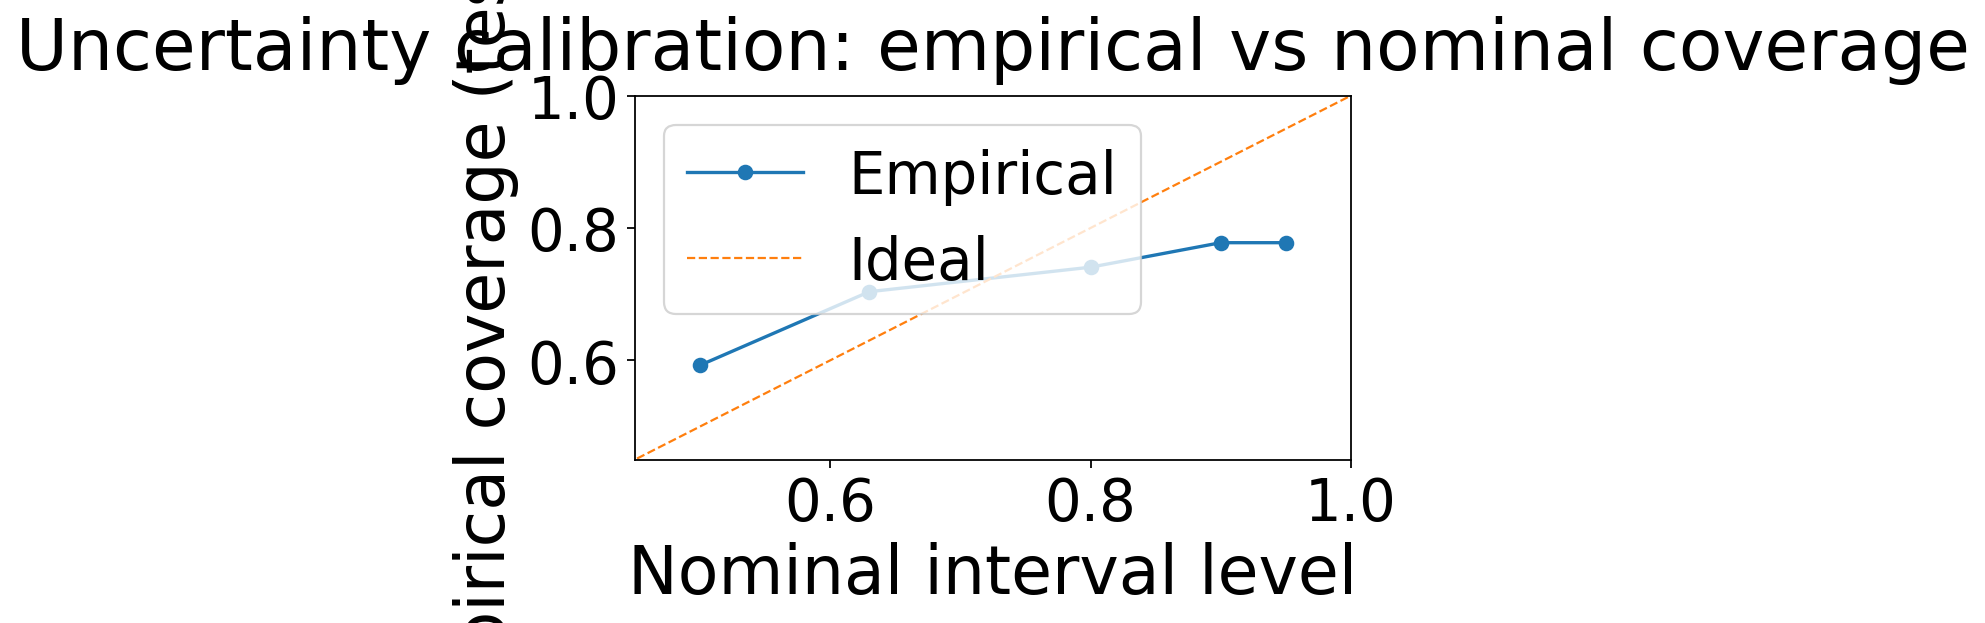

Saved: fig_calibration_coverage_curve.png
[Gaussian z] Level 0.63: empirical coverage = 0.704
[Gaussian z] Level 0.95: empirical coverage = 0.778
✓ Wrote feature_engineer.py


ElementProperty:   0%|          | 0/15 [00:00<?, ?it/s]

✓ Saved predictions → cte_predictions_XGB_NormalNLL.csv

=== PLOT SANITY TABLE (what is actually being plotted) ===
                                Formula       Exp        Mu         Sigma           Err  |Err|/Sigma
0                              Y3Al5O12  0.000009  0.000009  6.317222e-07 -1.553950e-07     0.245986
1             Y.6La.6Dy.6Ho.6Er.6Al5O12  0.000009  0.000009  6.405681e-07 -7.461600e-08     0.116484
2             Y.6Eu.6Dy.6Ho.6Er.6Al5O12  0.000009  0.000009  6.317222e-07  1.532090e-07     0.242526
3         Y.60Nd.60Dy.60Ho.60Er.6Al5O12  0.000009  0.000009  6.317222e-07  9.579800e-08     0.151646
4   Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12  0.000009  0.000009  6.317222e-07  1.232120e-07     0.195041
5      Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12  0.000009  0.000009  7.266067e-07  9.277600e-08     0.127684
6                              Y3Fe5O12  0.000011  0.000011  7.170017e-07 -1.103725e-07     0.153936
7                     Y3Fe2.50Al2.50O12  0.000010  0.000009  6.317222e-07 -6

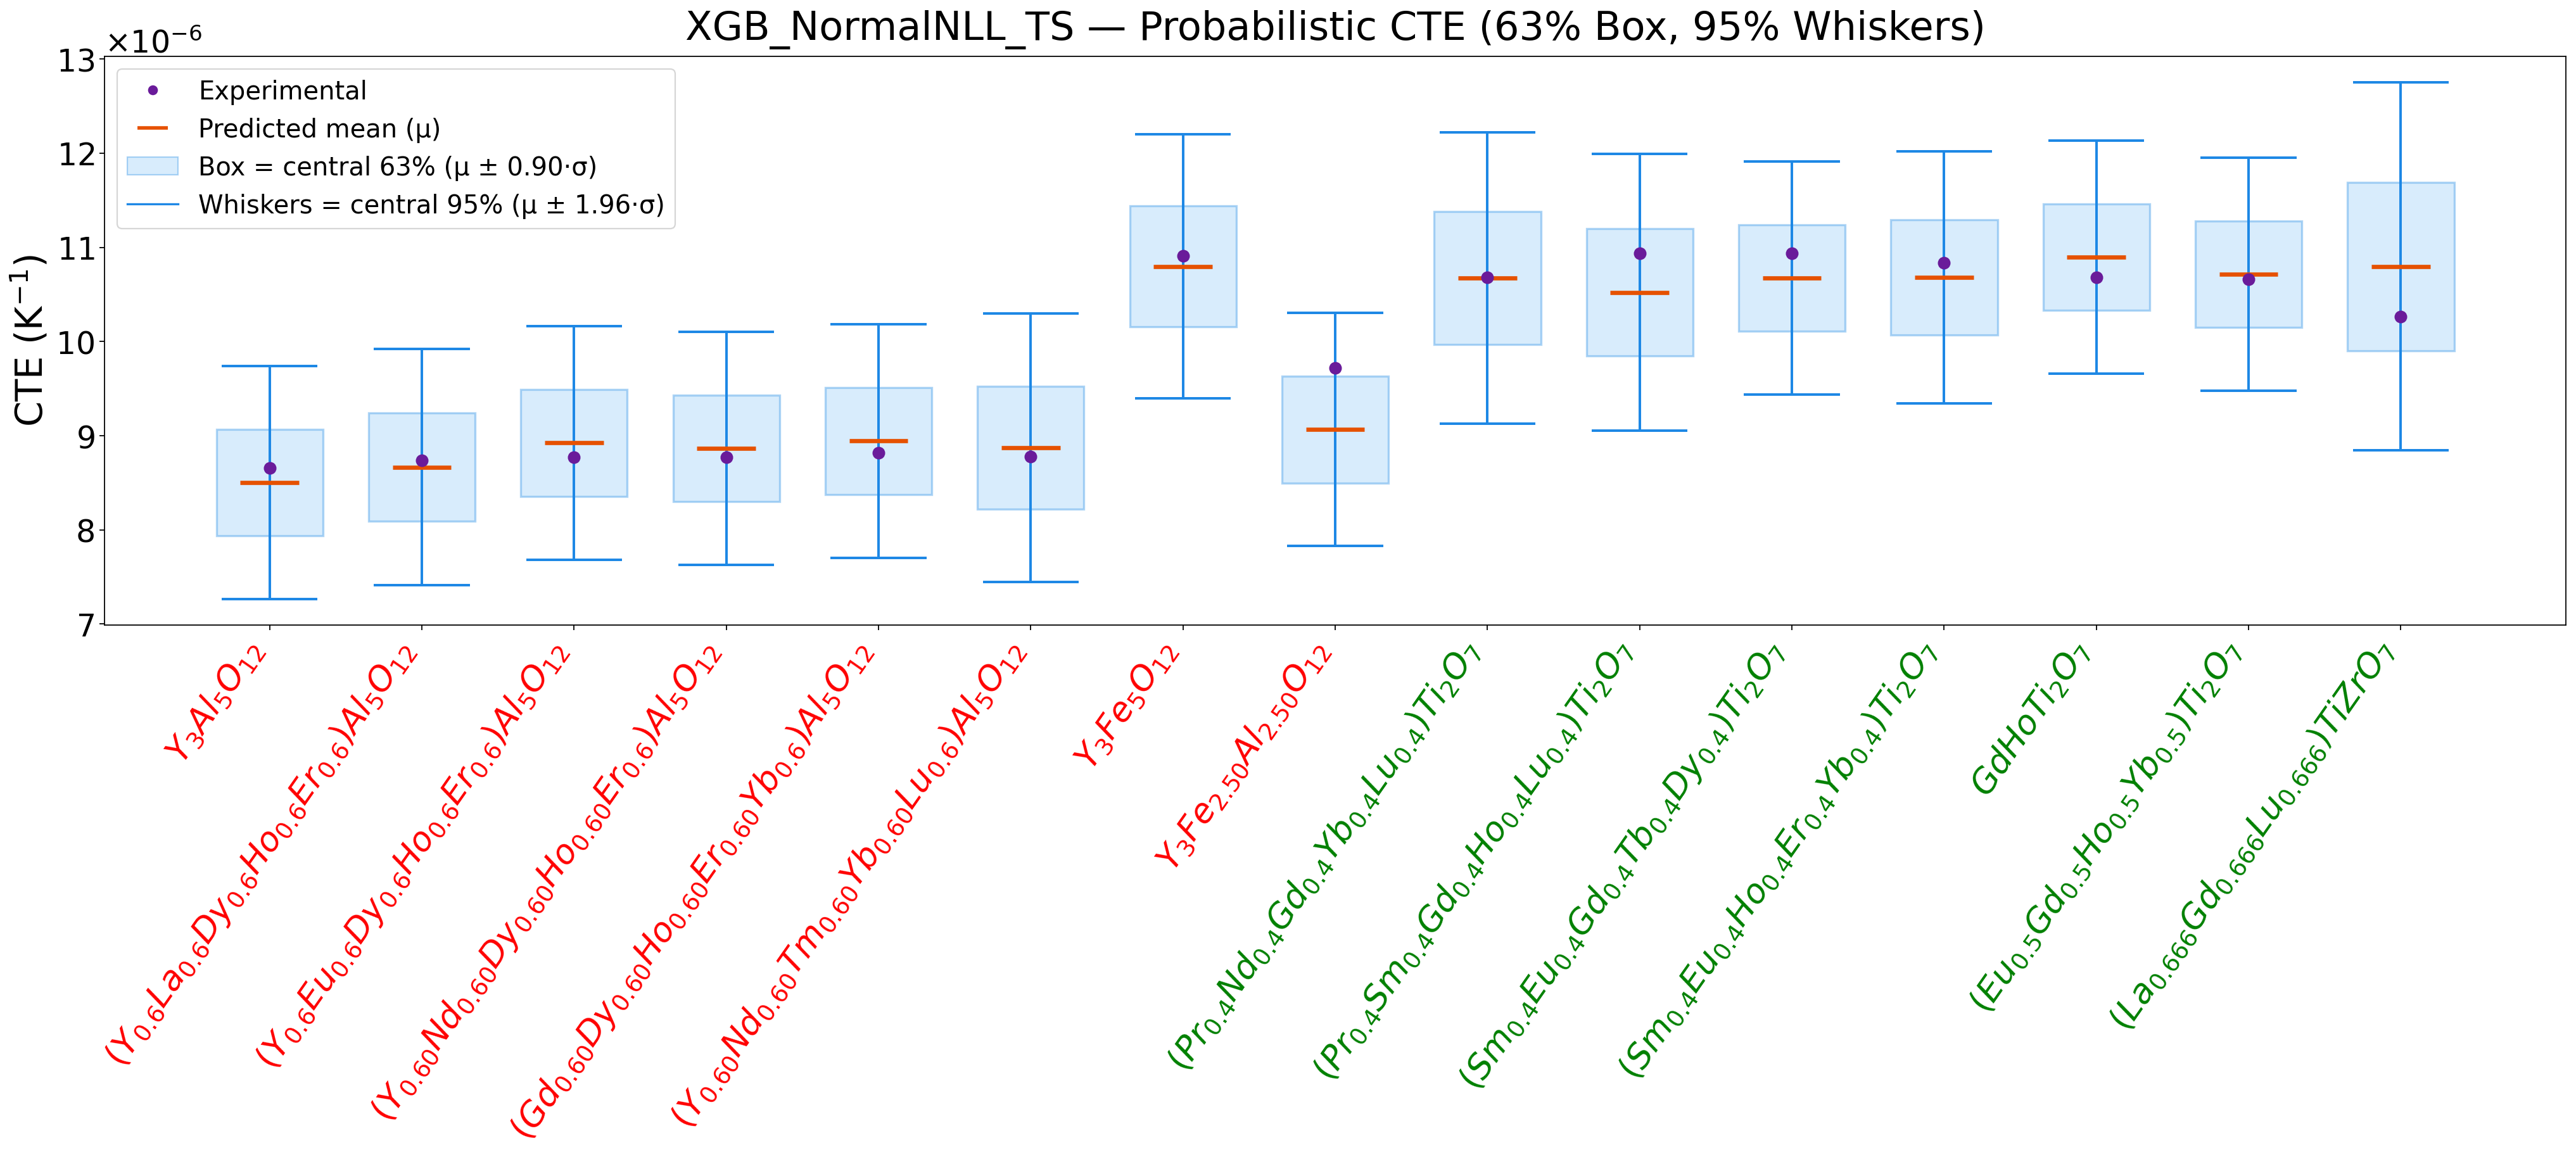

Saved readable plot → cte_prob_boxes_xgbn.png


In [ ]:
# XGB_NormalNLL two-stage
# Stage 1: μ via XGBoost (squarederror)
# Stage 2: logσ via custom NormalNLL objective
# σ calibrated on CALIB so that μ ± z95*(k·σ) hits target coverage
# Plot:
#   Box      = central 63% interval (μ ± 0.90σ)
#   Whiskers = central 95% interval (μ ± 1.96σ)

import os, re, json, textwrap, importlib.util, warnings, random
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from joblib import dump, load
from scipy.stats import norm

warnings.filterwarnings("ignore")

# HARD DETERMINISM / SEEDING
RANDOM_STATE = 42

def set_all_seeds(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_all_seeds(RANDOM_STATE)

# CONFIG
DO_TRAIN = True

ALLOW_OVERWRITE_MODELS = True

DATA_PATH = "composition_features_pymatgen.csv"
TARGET = "CTE Value"
DROP_COLS = ["Composition", "Composition_clean", "input",
             "normalized", "pretty_formula", "Unnamed: 0"]

TEST_SIZE = 0.2
CALIB_FRACTION = 0.2

# XGB params (seeded + deterministic)
XGB_PARAMS = dict(
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,

    # determinism
    seed=RANDOM_STATE,
    random_state=RANDOM_STATE,
    nthread=1,
    tree_method="hist",
)

ROUNDS_MU = 3000
EARLY_STOP = 100

# σ-head params
ROUNDS_S = 600
S_CLIP = (-5.0, 5.0)
XGB_PARAMS_SIG = dict(XGB_PARAMS, reg_lambda=2.0, reg_alpha=0.5)

# Calibration target
CALIB_COVERAGE = 0.95

# Sigma calibration & floor
CALIBRATE_SIGMA = True
SIGMA_FLOOR_FRAC = 0.05

# Artifacts
X_IMPUTER_PATH = "x_imputer_train.joblib"
X_TRAIN_FEATS  = "x_train_feature_names.json"
Y_SCALER_JOBLIB = "y_scaler.joblib"
MU_JSON  = "xgbn_mu.json"
S_JSON   = "xgbn_s.json"
CALIB_JSON = "prob_calibration.json"

# Inference I/O
PRED_CSV = "cte_predictions_XGB_NormalNLL.csv"

# Plot I/O
OUT_PNG  = "cte_prob_boxes_xgbn.png"
OUT_CALIB_CURVE = "fig_calibration_coverage_curve.png"


# Utilities
def load_dataframe(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"DATA_PATH not found: {path}")
    return pd.read_csv(path)

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    cols = (
        df.drop(columns=[c for c in [TARGET] + DROP_COLS if c in df.columns],
                errors="ignore")
          .select_dtypes(include=[np.number])
          .columns
          .tolist()
    )
    return cols

def empirical_coverage(y, mu, sig, level: float) -> float:
    alpha = 1.0 - level
    z = norm.ppf(1.0 - alpha/2.0)
    lo = mu - z * sig
    hi = mu + z * sig
    return float(np.mean((y >= lo) & (y <= hi)))

def plot_coverage_curve(y, mu, sig, out_png=OUT_CALIB_CURVE):
    levels = [0.50, 0.63, 0.80, 0.90, 0.95]
    cov = [empirical_coverage(y, mu, sig, L) for L in levels]

    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    ax.plot(levels, cov, marker="o", label="Empirical")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Ideal")
    ax.set_xlabel("Nominal interval level")
    ax.set_ylabel("Empirical coverage (test set)")
    ax.set_title("Uncertainty calibration: empirical vs nominal coverage")
    ax.set_xlim(0.45, 1.00)
    ax.set_ylim(0.45, 1.00)
    ax.legend()

    fig.tight_layout()
    fig.savefig(out_png, dpi=300)
    plt.show()
    print("Saved:", out_png)

    for L, C in zip(levels, cov):
        if np.isclose(L, 0.63) or np.isclose(L, 0.95):
            print(f"[Gaussian z] Level {L:.2f}: empirical coverage = {C:.3f}")

# custom objective for logσ
def obj_s(pred_s, dtrain):
    """
    NormalNLL objective for logσ:
      L = log σ^2 + r^2 / σ^2
      σ = exp(pred_s), r = y - μ
    """
    y  = dtrain.get_label()
    mu = dtrain.get_base_margin()
    r = y - mu
    invs2 = np.exp(-2.0 * pred_s)
    grad = 1.0 - (r * r) * invs2
    hess = 2.0 * (r * r) * invs2
    return grad, np.clip(hess, 1e-12, None)

# TRAIN
def train_two_stage() -> Dict[str, Any]:
    print("=== TRAIN: loading data ===")
    df = load_dataframe(DATA_PATH)
    if TARGET not in df.columns:
        raise ValueError(f"Target column '{TARGET}' not found in {DATA_PATH}")

    y_raw = df[TARGET].astype(float)
    feats = get_feature_columns(df)
    X_raw = df[feats].copy()

    imp = SimpleImputer(strategy="median")
    X_all = imp.fit_transform(X_raw)

    # save train artifacts
    dump(imp, X_IMPUTER_PATH)
    with open(X_TRAIN_FEATS, "w") as f:
        json.dump(feats, f)
    print(f"✓ Saved TRAIN imputer → {X_IMPUTER_PATH}")
    print(f"✓ Saved TRAIN feature list → {X_TRAIN_FEATS}")
    print(f"✓ #features = {len(feats)}")

    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y_raw.values.reshape(-1, 1)).ravel()
    dump(y_scaler, Y_SCALER_JOBLIB)
    print(f"✓ Saved y scaler → {Y_SCALER_JOBLIB}")

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_all, y_scaled, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    X_train_core, X_calib, y_train_core, y_calib = train_test_split(
        X_train_full, y_train_full, test_size=CALIB_FRACTION, random_state=RANDOM_STATE
    )

    inv_y = lambda z: y_scaler.inverse_transform(np.asarray(z).reshape(-1, 1)).ravel()

    # Stage 1: μ
    dtr  = xgb.DMatrix(X_train_core, label=y_train_core)
    dcal = xgb.DMatrix(X_calib,     label=y_calib)
    dte  = xgb.DMatrix(X_test,      label=y_test)

    mu_params = dict(XGB_PARAMS)
    mu_params["objective"] = "reg:squarederror"

    bst_mu = xgb.train(
        params=mu_params,
        dtrain=dtr,
        num_boost_round=ROUNDS_MU,
        evals=[(dtr, "train"), (dcal, "calib")],
        early_stopping_rounds=EARLY_STOP,
        verbose_eval=False,
    )

    mu_tr_sc  = bst_mu.predict(dtr)
    mu_cal_sc = bst_mu.predict(dcal)
    mu_te_sc  = bst_mu.predict(dte)

    mu_te      = inv_y(mu_te_sc)
    y_test_org = inv_y(y_test)

    rmse_plain = float(np.sqrt(mean_squared_error(y_test_org, mu_te)))
    r2_plain   = float(r2_score(y_test_org, mu_te))
    print(f"Plain XGB (μ): R²={r2_plain: .4f} | RMSE= {rmse_plain: .6e}")

    # Stage 2: σ (logσ)
    def fit_sigma_head(X_core, mu_core_sc, y_core_sc, X_eval, mu_eval_sc, y_eval_sc):
        dtr_s  = xgb.DMatrix(X_core, label=y_core_sc)
        dtr_s.set_base_margin(mu_core_sc)
        dval_s = xgb.DMatrix(X_eval, label=y_eval_sc)
        dval_s.set_base_margin(mu_eval_sc)

        bst_s = xgb.train(
            params=XGB_PARAMS_SIG,
            dtrain=dtr_s,
            num_boost_round=ROUNDS_S,
            obj=obj_s,
            evals=[(dtr_s, "train_s"), (dval_s, "eval_s")],
            verbose_eval=False,
        )
        return bst_s

    bst_s = fit_sigma_head(
        X_train_core, mu_tr_sc, y_train_core,
        X_calib,      mu_cal_sc, y_calib
    )

    # Predict σ on test (scaled space -> original space)
    dte_s = xgb.DMatrix(X_test)
    dte_s.set_base_margin(mu_te_sc)
    s_te_sc = np.clip(bst_s.predict(dte_s), S_CLIP[0], S_CLIP[1])
    sigma_te_sc = np.exp(s_te_sc)

    y_scale = float(y_scaler.scale_[0])
    sigma_te = sigma_te_sc * y_scale

    # Sigma floor + calibration on CALIB
    k_scale = 1.0
    sigma_floor = 0.0

    if CALIBRATE_SIGMA:
        mu_cal = inv_y(mu_cal_sc)
        y_cal_org = inv_y(y_calib)

        dcal_s = xgb.DMatrix(X_calib)
        dcal_s.set_base_margin(mu_cal_sc)
        s_cal_sc = np.clip(bst_s.predict(dcal_s), S_CLIP[0], S_CLIP[1])
        sigma_cal_sc = np.exp(s_cal_sc)
        sigma_cal = sigma_cal_sc * y_scale

        abs_res = np.abs(y_cal_org - mu_cal)

        sigma_floor = float(SIGMA_FLOOR_FRAC * np.nanmedian(abs_res))
        sigma_floor = sigma_floor if np.isfinite(sigma_floor) and sigma_floor > 0 else 1e-12

        sigma_cal = np.maximum(sigma_cal, sigma_floor)
        sigma_te  = np.maximum(sigma_te,  sigma_floor)

        tgt = float(CALIB_COVERAGE)
        z95 = float(norm.ppf((1.0 + tgt) / 2.0))
        u = abs_res / np.maximum(z95 * sigma_cal, 1e-30)
        u = u[np.isfinite(u)]
        k_scale = float(np.quantile(u, tgt))
        k_scale = max(k_scale, 1e-6)

        lo_c = mu_cal - z95 * (k_scale * sigma_cal)
        hi_c = mu_cal + z95 * (k_scale * sigma_cal)
        calib_cov = float(np.mean((y_cal_org >= lo_c) & (y_cal_org <= hi_c)))

        print(
            f"σ-calibration (CALIB): z95={z95:.3f}, k={k_scale:.3f}, "
            f"floor={sigma_floor:.3e}, CALIB_cov@{tgt:.2f}={calib_cov:.3f}"
        )

        sigma_te = sigma_te * k_scale

    # TEST coverage report
    z95 = float(norm.ppf((1.0 + CALIB_COVERAGE) / 2.0))
    lo = mu_te - z95 * sigma_te
    hi = mu_te + z95 * sigma_te
    coverage = float(np.mean((y_test_org >= lo) & (y_test_org <= hi)))
    print(
        f"Two-stage (μ+σ): R²={r2_plain: .4f} | RMSE= {rmse_plain: .6e} | "
        f"TEST Coverage@{CALIB_COVERAGE:.2f}≈{coverage:.3f}"
    )

    np.savez(
        "calibration_arrays_test.npz",
        y=np.asarray(y_test_org).ravel(),
        mu=np.asarray(mu_te).ravel(),
        sig=np.asarray(sigma_te).ravel(),
    )
    print("Saved calibration arrays → calibration_arrays_test.npz")

    if (not ALLOW_OVERWRITE_MODELS) and (os.path.exists(MU_JSON) or os.path.exists(S_JSON)):
        raise RuntimeError(
            "Model files exist and ALLOW_OVERWRITE_MODELS=False. "
            "Set DO_TRAIN=False or allow overwrite intentionally."
        )

    bst_mu.save_model(MU_JSON)
    bst_s.save_model(S_JSON)
    with open(CALIB_JSON, "w") as f:
        json.dump(
            {
                "k_scale": k_scale,
                "calib_coverage": CALIB_COVERAGE,
                "sigma_floor": sigma_floor,
                "random_state": RANDOM_STATE,
            },
            f,
        )

    print(f"✓ Saved boosters → {MU_JSON}, {S_JSON}")
    print(f"✓ Saved sigma calibration → {CALIB_JSON}")

    return {
        "y_test_org": y_test_org,
        "mu_te": mu_te,
        "sigma_te": sigma_te,
    }

# Write featurizer
def write_featurizer():
    fe_code = r'''
from __future__ import annotations
import re, math
from typing import List, Tuple
import numpy as np, pandas as pd
from pymatgen.core.composition import Composition
from matminer.featurizers.composition import ElementProperty

def _normalize_formula(s: str) -> str:
    s = s.replace(" ", "")
    return re.sub(r'(?<=[A-Za-z\)])\.(\d)', r'0.\1', s)

def _compute_ionic_stats(formula: str) -> Tuple[float|None, float|None, float|None]:
    try:
        comp = Composition(formula)
        elements = comp.elements
        fractions = [comp.get_atomic_fraction(el) for el in elements]
        ionic_radii, atomic_masses, symbols = [], [], []
        for el in elements:
            ox_states = el.common_oxidation_states
            ox_state = ox_states[0] if ox_states else None
            radius = None
            try:
                radius = el.ionic_radii.get(ox_state, None) if ox_state is not None else None
            except Exception:
                radius = None
            ionic_radii.append(radius)
            atomic_masses.append(float(el.atomic_mass))
            symbols.append(el.symbol)

        valid = [(r, f) for r, f in zip(ionic_radii, fractions) if r is not None]
        if not valid:
            return None, None, None
        radii, fracs = zip(*valid)
        avg_radius = sum(r * f for r, f in zip(radii, fracs))
        var_radius = sum(f * (r - avg_radius) ** 2 for f, r in zip(fracs, radii))
        std_radius = math.sqrt(var_radius)
        mismatch_pct = (std_radius / avg_radius) * 100 if avg_radius else None

        # mass heterogeneity (exclude O)
        c_masses = [m for m, s in zip(atomic_masses, symbols) if s != "O"]
        c_fracs  = [f for s, f in zip(symbols, fractions) if s != "O"]
        if not c_masses or not c_fracs:
            return (round(avg_radius, 4) if avg_radius is not None else None,
                    round(mismatch_pct, 2) if mismatch_pct is not None else None,
                    None)
        total_frac = sum(c_fracs) or 1.0
        norm_fracs = [f / total_frac for f in c_fracs]
        mean_mass = sum(m * f for m, f in zip(c_masses, norm_fracs))
        mdiff = ((max(c_masses) - min(c_masses)) / mean_mass) * 100 if mean_mass else None

        return (
            None if avg_radius is None else round(avg_radius, 4),
            None if mismatch_pct is None else round(mismatch_pct, 2),
            None if mdiff is None else round(mdiff, 2),
        )
    except Exception:
        return None, None, None

def _build_magpie_features(formulas: List[str]) -> pd.DataFrame:
    recs = []
    for f in formulas:
        f_norm = _normalize_formula(f)
        try:
            comp = Composition(f_norm)
        except Exception:
            comp = None
        recs.append({"formula_key": f_norm, "composition_obj": comp})
    df = pd.DataFrame(recs)
    featurizer = ElementProperty.from_preset("magpie")
    df = featurizer.featurize_dataframe(df, "composition_obj", ignore_errors=True)
    df.drop(columns=["composition_obj"], inplace=True)
    return df

def build_feature_matrix(formulas: List[str]) -> pd.DataFrame:
    f_norm = [_normalize_formula(f) for f in formulas]
    base = pd.DataFrame({"formula_key": f_norm})
    ion = [_compute_ionic_stats(f) for f in f_norm]
    ion = pd.DataFrame(
        ion,
        columns=[
            "Avg Ionic Radius (Å)",
            "Ionic Size Mismatch (%)",
            "Atomic Mass Diff (%)",
        ],
    )
    base = pd.concat([base, ion], axis=1)
    mag = _build_magpie_features(f_norm)
    base = base.merge(mag, on="formula_key", how="left")
    base.insert(0, "Formula", formulas)
    base = base.drop(columns=["formula_key"])
    return base
'''
    with open("feature_engineer.py", "w") as f:
        f.write(textwrap.dedent(fe_code))
    print("✓ Wrote feature_engineer.py")

# INFERENCE
def infer_xgb_normalnll(formulas: List[str]) -> pd.DataFrame:
    if not (os.path.exists(MU_JSON) and os.path.exists(S_JSON)):
        raise FileNotFoundError("Missing trained model JSONs. Train first or provide saved models.")
    if not (os.path.exists(X_IMPUTER_PATH) and os.path.exists(X_TRAIN_FEATS) and os.path.exists(Y_SCALER_JOBLIB)):
        raise FileNotFoundError("Missing train artifacts (imputer/feature list/y_scaler). Train first.")

    # load featurizer
    spec = importlib.util.spec_from_file_location("feature_engineer", "feature_engineer.py")
    fe = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(fe)
    X_full = fe.build_feature_matrix(formulas)

    imp = load(X_IMPUTER_PATH)
    with open(X_TRAIN_FEATS, "r") as f:
        feats = json.load(f)
    y_scaler = load(Y_SCALER_JOBLIB)

    # FORCE exact feature set + order
    for c in feats:
        if c not in X_full.columns:
            X_full[c] = np.nan
    X_imp = imp.transform(X_full[feats].values)

    bst_mu = xgb.Booster()
    bst_mu.load_model(MU_JSON)
    bst_s = xgb.Booster()
    bst_s.load_model(S_JSON)

    dmx = xgb.DMatrix(X_imp)
    mu_sc = bst_mu.predict(dmx)

    dmx_s = xgb.DMatrix(X_imp)
    dmx_s.set_base_margin(mu_sc)
    s_sc = np.clip(bst_s.predict(dmx_s), S_CLIP[0], S_CLIP[1])
    sigma_sc = np.exp(s_sc)

    mu = y_scaler.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
    sigma = sigma_sc * float(y_scaler.scale_[0])

    # load calibration
    k_scale = 1.0
    sigma_floor = 0.0
    if os.path.exists(CALIB_JSON):
        with open(CALIB_JSON, "r") as f:
            cj = json.load(f)
        k_scale = float(cj.get("k_scale", 1.0))
        sigma_floor = float(cj.get("sigma_floor", 0.0))

    if sigma_floor and np.isfinite(sigma_floor):
        sigma = np.maximum(sigma, sigma_floor)
    sigma = np.maximum(sigma * k_scale, 1e-12)

    out = pd.DataFrame(
        {
            "Formula": np.asarray(formulas),
            "XGB_NormalNLL_TS_mean": mu,
            "XGB_NormalNLL_TS_std": sigma,
        }
    )
    out.to_csv(PRED_CSV, index=False)
    print(f"✓ Saved predictions → {PRED_CSV}")
    return out

# EXP data + plot order
experimental_data = {
    "Y3Al5O12": 8.660000000e-6,
    "Y.6La.6Dy.6Ho.6Er.6Al5O12": 8.740000000e-6,
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12": 8.770000000e-6,
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12": 8.770000000e-6,
    "Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12": 8.820000000e-6,
    "Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12": 8.780000000e-6,
    "Y3Fe5O12": 1.091000000e-5,
    "Y3Fe2.50Al2.50O12": 9.720000000e-6,
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7": 1.068328000e-5,
    "Pr.4Sm.4Gd.4Ho.4Lu.4Ti2O7": 1.094065000e-5,
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7": 1.093496000e-5,
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7": 1.083446000e-5,
    "GdHoTi2O7": 1.068365000e-5,
    "Eu0.5Gd0.5Ho0.5Yb0.5Ti2O7": 1.066338000e-5,
    "La.666Gd.666Lu.666TiZrO7": 10.26370957e-6,
}

plot_order = [
    "Y3Al5O12",
    "Y.6La.6Dy.6Ho.6Er.6Al5O12",
    "Y.6Eu.6Dy.6Ho.6Er.6Al5O12",
    "Y.60Nd.60Dy.60Ho.60Er.6Al5O12",
    "Gd0.60Dy0.60Ho0.60Er0.60Yb0.6Al5O12",
    "Y0.60Nd.60Tm.60Yb0.60Lu0.6Al5O12",
    "Y3Fe5O12",
    "Y3Fe2.50Al2.50O12",
    "Pr.4Nd.4Gd.4Yb.4Lu.4Ti2O7",
    "Pr.4Sm.4Gd.4Ho.4Lu.4Ti2O7",
    "Sm.4Eu.4Gd.4Tb.4Dy.4Ti2O7",
    "Sm.4Eu.4Ho.4Er.4Yb.4Ti2O7",
    "GdHoTi2O7",
    "Eu0.5Gd0.5Ho0.5Yb0.5Ti2O7",
    "La.666Gd.666Lu.666TiZrO7",
]

def _mixed_site_label(formula: str) -> str:
    """
    Keep mixed-site partial occupancies explicitly, but remove commas.
    Example:
      Pr.4Sm.4Gd.4Ho.4Lu.2Ti2O7 -> (Pr0.4Sm0.4Gd0.4Ho0.4Lu0.2)Ti2O7
    If there is no leading fractional run, returns the original formula.
    """
    tokens = re.findall(r'([A-Z][a-z]*)([0-9.]*)', formula)
    if not tokens:
        return formula

    elems, nums = [], []
    for el, num in tokens:
        elems.append(el)
        if num.strip() == "":
            nums.append(None)
        else:
            # ".4" -> "0.4"
            num_norm = ("0" + num) if num.startswith(".") else num
            nums.append(num_norm)

    i = 0
    while i < len(nums):
        n = nums[i]
        if n is None:
            break
        try:
            if float(n) < 1.0:
                i += 1
                continue
        except Exception:
            break
        break

    if i == 0:
        return formula

    mixed = []
    for el, n in zip(elems[:i], nums[:i]):
        mixed.append(f"{el}{n}")

    rest = []
    for el, n in zip(elems[i:], nums[i:]):
        if n is None or (isinstance(n, str) and n.strip() in ("", "1")):
            rest.append(f"{el}")
        else:
            rest.append(f"{el}{n}")

    return "(" + "".join(mixed) + ")" + "".join(rest)

def formula_to_mathtext(formula: str) -> str:
    """
    Convert label (including mixed-site parentheses) into Matplotlib mathtext
    with subscripts. Keeps decimals.
    Example:
      (Pr0.4Sm0.4Lu0.2)Ti2O7 -> $(Pr_{0.4}Sm_{0.4}Lu_{0.2})Ti_{2}O_{7}$
    """
    s = _mixed_site_label(formula)

    s = re.sub(
        r'(?<=[A-Za-z\)])([0-9]+(?:\.[0-9]+)?)',
        r'_{\1}',
        s
    )
    return f"${s}$"

def plot_prob_boxes(pred_csv=PRED_CSV, out_png=OUT_PNG):
    if not os.path.exists(pred_csv):
        raise FileNotFoundError(pred_csv)
    df = pd.read_csv(pred_csv)

    mu_col = "XGB_NormalNLL_TS_mean"
    sd_col = "XGB_NormalNLL_TS_std"
    if mu_col not in df.columns or sd_col not in df.columns:
        raise ValueError("Expected probabilistic columns not found in predictions CSV.")

    df = df[df["Formula"].isin(experimental_data.keys())].copy()
    df["Experimental"] = df["Formula"].map(experimental_data)

    idx = {f: i for i, f in enumerate(plot_order)}
    df["__ord__"] = df["Formula"].map(idx)
    df.sort_values("__ord__", inplace=True, kind="mergesort")
    df.drop(columns="__ord__", inplace=True)

    labels = [formula_to_mathtext(f) for f in df["Formula"].tolist()]
    mu  = df[mu_col].to_numpy(dtype=float)
    sd  = df[sd_col].to_numpy(dtype=float)
    yexp = df["Experimental"].to_numpy(dtype=float)

    sanity = pd.DataFrame({
        "Formula": df["Formula"].values,
        "Exp": yexp,
        "Mu": mu,
        "Sigma": sd,
        "Err": (mu - yexp),
    })
    sanity["|Err|/Sigma"] = np.abs(sanity["Err"]) / np.maximum(sanity["Sigma"], 1e-30)
    print("\n=== PLOT SANITY TABLE (what is actually being plotted) ===")
    print(sanity.to_string(index=True))

    pos = np.isfinite(sd) & (sd > 0)
    fallback = np.nanmedian(sd[pos]) if np.any(pos) else 1e-12
    sd = np.where(pos, sd, fallback)

    x = np.arange(len(labels))
    box_half = 0.35

    BOX_COVERAGE = 0.63
    WHISKER_COVERAGE = 0.95
    z_box   = norm.ppf((1.0 + BOX_COVERAGE) / 2.0)      # ~0.90
    z_whisk = norm.ppf((1.0 + WHISKER_COVERAGE) / 2.0)  # ~1.96

    plt.rcParams.update({
        "font.size": 26,
        "xtick.labelsize": 24,
        "ytick.labelsize": 22,
        "axes.labelsize": 26,
        "axes.titlesize": 28,
        "legend.fontsize": 18,
    })

    plt.figure(figsize=(26, 12))
    ax = plt.gca()

    for i, (m, s) in enumerate(zip(mu, sd)):
        low_box, high_box = m - z_box * s,   m + z_box * s
        low_wh,  high_wh  = m - z_whisk * s, m + z_whisk * s

        rect = Rectangle(
            (i - box_half, low_box),
            2 * box_half,
            (high_box - low_box),
            facecolor="#90CAF9",
            edgecolor="#1E88E5",
            alpha=0.35,
            linewidth=1.5,
        )
        ax.add_patch(rect)

        ax.vlines(i, low_wh, high_wh, linewidth=1.8, color="#1E88E5")
        cap_w = box_half * 0.9
        ax.hlines([low_wh, high_wh], i - cap_w, i + cap_w,
                  linewidth=1.8, color="#1E88E5")

        # μ tick
        mean_half = box_half * 0.55
        ax.hlines(m, i - mean_half, i + mean_half, color="#E65100", linewidth=3.0)

    ax.plot(x, yexp, "o", markersize=8, color="#6A1B9A", label="Experimental")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right")

    for tick_text, raw_formula in zip(ax.get_xticklabels(),
                                     df["Formula"].tolist()):
        if "O12" in raw_formula:
            tick_text.set_color("red")
        elif "O7" in raw_formula:
            tick_text.set_color("green")

    ax.set_ylabel(r"CTE (K$^{-1}$)")

    y_min = min(np.min(yexp), np.min(mu - z_whisk * sd))
    y_max = max(np.max(yexp), np.max(mu + z_whisk * sd))
    pad = 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - pad, y_max + pad)

    sf = mticker.ScalarFormatter(useMathText=True)
    sf.set_scientific(True)
    sf.set_powerlimits((-6, -6))
    ax.yaxis.set_major_formatter(sf)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
    ax.yaxis.get_offset_text().set_size(22)

    exp_dot, = ax.plot([], [], "o", color="#6A1B9A", label="Experimental")
    mean_tick, = ax.plot(
        [], [],
        marker="_",
        linestyle="none",
        color="#E65100",
        markersize=22,
        markeredgewidth=2.5,
        label="Predicted mean (μ)"
    )

    box_patch = Rectangle(
        (0, 0), 1, 1,
        facecolor="#90CAF9",
        edgecolor="#1E88E5",
        alpha=0.35,
        label=f"Box = central 63% (μ ± {z_box:.2f}·σ)",
    )
    whisker_line, = ax.plot(
        [], [], color="#1E88E5",
        label=f"Whiskers = central 95% (μ ± {z_whisk:.2f}·σ)",
    )
    ax.legend(handles=[exp_dot, mean_tick, box_patch, whisker_line],
              loc="upper left", frameon=True)

    ax.set_title("XGB_NormalNLL_TS — Probabilistic CTE (63% Box, 95% Whiskers)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved readable plot → {out_png}")

# MAIN
NEW_FORMULAS = plot_order

def write_and_run():
    write_featurizer()
    _ = infer_xgb_normalnll(NEW_FORMULAS)
    plot_prob_boxes(PRED_CSV, OUT_PNG)

train_out = None
if DO_TRAIN:
    train_out = train_two_stage()
    plot_coverage_curve(
        y=np.asarray(train_out["y_test_org"]).ravel(),
        mu=np.asarray(train_out["mu_te"]).ravel(),
        sig=np.asarray(train_out["sigma_te"]).ravel(),
        out_png=OUT_CALIB_CURVE
    )

write_and_run()
